# Lab: Deep Q-Networks (DQN) — The Mountain Car And Atari Breakout


## Learning Objectives

By the end of this lab you will be able to:

1. Explain **why tabular Q-learning fails** on continuous state spaces and how DQN addresses this.
2. Implement a **Deep Q-Network** from scratch using PyTorch.
3. Understand and implement the key DQN innovations: **experience replay** and a **target network**.
4. Train an agent to solve the **Mountain Car** environment (`MountainCar-v0`).
5. Train an agent to solve the **Atari Breakout** environment (`ALE/Breakout-v5`).
6. Design and run **ablation experiments** to understand how each component contributes to learning.
7. Critically analyze training curves and agent behaviour.

## TO DO

**For the Mountain car env, you are required to complete the implementation of Replay Buffer, Q-Network, and Agent, then run the ablation experiments, and answer the five discussion questions at the end. 
For the Atari evn, you are again required to complete the implementation of Replay Buffer, Q-Network, and Agent and write a brief reflection at the end on the similarities and differences between your implementation of the same components for two different environments.** 

---

## Background: Why DQN?

In previous labs you implemented tabular Q-learning where the Q-function was stored as a table indexed by *(state, action)* pairs. This works well when the state space is small and discrete, but the Mountain Car environment has a **continuous** 2D state space (position × velocity). Discretising it into a fine grid leads to a huge table and slow convergence.

**Deep Q-Networks** replace the Q-table with a neural network $Q_\theta(s, a)$ that takes a state $s$ as input and outputs Q-values for every action. The network is trained by minimising the temporal-difference (TD) error:

$$\mathcal{L}(\theta) = \mathbb{E}_{(s,a,r,s') \sim \mathcal{D}} \Big[\big(r + \gamma \max_{a'} Q_{\theta^-}(s', a') - Q_\theta(s, a)\big)^2\Big]$$

where $\mathcal{D}$ is a **replay buffer** and $\theta^-$ are the parameters of a slowly-updated **target network**.

--- 

# Deep Q-Network (DQN), Off-policy Deep Q-learning

## Algorithm

**1. Initialization**

- Initialize **Q-network** with random weights $\theta$
- Initialize **target network** with weights $\theta^{-} \leftarrow \theta$
- Initialize **experience replay buffer** $\mathcal{D}$
- Set learning rate $\alpha$, discount factor $\gamma$, exploration rate $\epsilon$, and target update frequency $C$

**2. Loop over $K$ episodes:**

&emsp; A. Initialize starting state $s_0$

&emsp; B. **For each step $t = 0, 1, 2, \ldots$ until termination:**

&emsp;&emsp; a. Choose action $a_t$ using the $\epsilon$-greedy policy derived from $Q_\theta$

$$a_t = \begin{cases} \text{random action,} & \text{with prob. } \epsilon \\ \arg\max_a Q_\theta(s_t, a), & \text{with prob. } 1 - \epsilon \end{cases}$$

&emsp;&emsp; b. Execute $a_t$, observe reward $R_{t+1}$ and next state $s_{t+1}$

&emsp;&emsp; c. Store transition $(s_t, a_t, R_{t+1}, s_{t+1})$ in replay buffer $\mathcal{D}$

&emsp;&emsp; d. Sample a mini-batch $\{(s_j, a_j, R_j, s_j')\}$ from $\mathcal{D}$

&emsp;&emsp; e. Compute the **TD target** using the target network:

$$\Delta_j = R_j + \gamma \max_{a'} Q_{\theta^{-}}(s_j', a')$$

&emsp;&emsp; f. Compute the **loss** on the Q-network:

$$L(\theta) = \frac{1}{N} \sum_j \left( \Delta_j - Q_\theta(s_j, a_j) \right)^2$$

&emsp;&emsp; g. **Update the Q-network** by one gradient step:

$$\theta \leftarrow \theta - \alpha \, \nabla_\theta L(\theta)$$

> Gradient $\nabla_\theta L(\theta)$ flows only through $Q_\theta(s_j, a_j)$; $Q_{\theta^{-}}$ is fixed (no gradient).

&emsp;&emsp; h. **Every $C$ steps**, update the target network:

$$\theta^{-} \leftarrow \theta$$

&emsp;&emsp; i. Update current state: $s_t \leftarrow s_{t+1}$

**3. After all episodes:**

- Derive the final **greedy policy**:

$$\pi(s) = \arg\max_a Q_\theta(s, a)$$

---

## Stabilization Mechanisms in DQN

### 1. Experience Replay — stabilizes gradient updates

- **Breaks temporal correlation:** Consecutive transitions $(s_t, a_t, R_{t+1}, s_{t+1})$ are highly correlated. Randomly sampling mini-batches from the replay buffer $\mathcal{D}$ approximates i.i.d. data, which reduces correlated gradient noise.

- **Smooths learning:** Averaging over diverse, past experiences prevents sudden parameter oscillations.

- **Improves sample efficiency:** Each stored transition can contribute to many gradient steps, leading to more stable and data-efficient training.

- **Reduces non-stationarity:** As $\theta$ changes, the policy and data distribution shift. Replay mitigates this drift by mixing old and new samples.

### 2. Delayed Target Network Update — prevents moving-target instability

- **TD error definition:** For a sampled transition $(s, a, R, s')$, the **temporal-difference (TD) error** is

$$\delta = R + \gamma \max_{a'} Q_{\theta^{-}}(s', a') - \underbrace{Q_\theta(s, a)}_{\text{Prediction side}}$$

  where $R + \gamma \max_{a'} Q_{\theta^{-}}(s', a')$ is the **target side**.

- **If both sides used $Q_\theta$ (same network):** The target term $R + \gamma \max_{a'} Q_\theta(s', a')$ would shift whenever $\theta$ changes, so the network would constantly chase a moving target → unstable learning.

- **Role of the target network:** By using a separate **target network** $Q_{\theta^{-}}$ (frozen for $C$ steps), the target side remains fixed while gradients $\nabla_\theta$ are applied only to $Q_\theta(s, a)$.

This decoupling makes the target evolve slowly, ensuring $Q_\theta$ converges toward a stable objective instead of diverging.

---

## Why DQN Prefers Off-policy Control?

### DQN learns from experience replay

- DQN stores transitions $(s_t, a_t, R_{t+1}, s_{t+1})$ in a replay buffer $\mathcal{D}$ and later samples them **out of order**.
- These experiences were collected **under many different past policies**, since $\epsilon$ (exploration rate) changes over time and the Q-network $\theta$ is constantly updated.
- **On-policy algorithms** (E.x. SARSA) require all samples to match the *current* policy $\pi_\theta$. Using old, mismatched samples would make their updates incorrect.
- **Off-policy learning** (E.x. Q-learning and DQN) don't have this restriction — it can learn the *optimal policy* $\pi^*$ from any behavior policy.

> ✅ Thus, experience replay naturally requires off-policy learning.

### Separation of exploration and learning

- Behavior policy (used to collect data): $\epsilon$-greedy → exploratory.
- Target policy (used in updates): greedy → optimal.
- This separation allows safe and consistent learning while still exploring the environment.

> ✅ The agent can explore freely without corrupting the direction of learning.
---

## The Mountain Car Environment

The Mountain Car problem is a classic RL benchmark. A car is placed near the bottom of a sinusoidal valley. The engine is too weak to climb the right hill directly, so the agent must learn to **rock back and forth** to build momentum.

### Environment Specification

| Property | Details |
|---|---|
| **State Space** | 2D continuous: position $x \in [-1.2, 0.6]$, velocity $\dot{x} \in [-0.07, 0.07]$ |
| **Action Space** | Discrete, 3 actions: `0` = push left, `1` = no push, `2` = push right |
| **Reward** | $-1$ for every time step (encourages reaching the goal quickly) |
| **Initial State** | Position uniformly random in $[-0.6, -0.4]$, velocity $= 0$ |
| **Termination** | Position $\geq 0.5$ (goal reached) **or** 200 time steps elapsed |

### Why is Mountain Car hard?

The reward is **extremely sparse**: the agent receives $-1$ every step and $0$ only upon reaching the flag. A random policy almost never reaches the goal within 200 steps, so the agent receives a constant reward of $-200$ and has no gradient signal to improve. This makes Mountain Car an excellent testbed for exploration strategies.

> **Think about it:** How does this sparse reward structure compare to environments like CartPole? What challenges does it pose for Q-learning?
---

## Setup and Imports

We begin by importing all necessary libraries. Make sure you have `gymnasium`, `torch`, and `matplotlib` installed in your environment.

```
pip install gymnasium torch matplotlib numpy
```


In [16]:
# ============================================================
# Cell: Imports and Configuration
# Purpose: Import all required libraries and set random seeds
#          for reproducibility.
# ============================================================

import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import random
import tempfile
import os
import torch.nn.functional as F
import ale_py
import gymnasium as gym
from gymnasium.wrappers import AtariPreprocessing, RecordVideo
from typing import NamedTuple
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, display, Image
import glob
from collections import deque, namedtuple
from IPython.display import clear_output
import warnings
warnings.filterwarnings('ignore')

# ----- Reproducibility -----
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ----- Device -----
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Using device: {DEVICE}")
print(f"PyTorch version: {torch.__version__}")
print(f"Gymnasium version: {gym.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
Gymnasium version: 1.2.3


## Environment Initialization & Exploration

Before building our agent, let's create the environment and understand its dynamics through direct interaction. This is an important step — you should always inspect an environment before designing an agent for it.


In [17]:
# ============================================================
# Cell: Environment Initialization
# Purpose: Create the MountainCar-v0 environment and inspect
#          its state/action spaces.
# ============================================================

env = gym.make("MountainCar-v0")

print("=" * 50)
print("ENVIRONMENT DETAILS")
print("=" * 50)
print(f"Observation space: {env.observation_space}")
print(f"  - Low bound:  {env.observation_space.low}")
print(f"  - High bound: {env.observation_space.high}")
print(f"Action space:     {env.action_space}")
print(f"  - Number of actions: {env.action_space.n}")
print(f"Action meanings:  0=Left, 1=Nothing, 2=Right")
print(f"Max episode steps: 200")

# Let's see what a single reset looks like
state, info = env.reset(seed=SEED)
print(f"\nInitial state: position={state[0]:.4f}, velocity={state[1]:.4f}")


ENVIRONMENT DETAILS
Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  - Low bound:  [-1.2  -0.07]
  - High bound: [0.6  0.07]
Action space:     Discrete(3)
  - Number of actions: 3
Action meanings:  0=Left, 1=Nothing, 2=Right
Max episode steps: 200

Initial state: position=-0.4452, velocity=0.0000


### Random Agent Baseline

Let's first see how a purely random agent performs. This gives us a baseline to compare our DQN against. We expect the random agent to almost always time out at 200 steps (total reward = $-200$).


In [18]:
# ============================================================
# Cell: Random Agent Baseline
# Purpose: Evaluate a random policy to establish a performance
#          baseline. The random agent should score around -200.
# ============================================================

def evaluate_random_agent(env, n_episodes=20, seed=SEED):
    """Run a random agent and return episode rewards."""
    rewards = []
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0
        done = False
        while not done:
            action = env.action_space.sample()  # random action
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated
        rewards.append(total_reward)
    return rewards

random_rewards = evaluate_random_agent(env)
print(f"Random Agent over 20 episodes:")
print(f"  Mean reward:  {np.mean(random_rewards):.1f}")
print(f"  Std reward:   {np.std(random_rewards):.1f}")
print(f"  Best reward:  {np.max(random_rewards):.1f}")
print(f"  Worst reward: {np.min(random_rewards):.1f}")
print(f"\nAs expected, the random agent almost never reaches the goal.")



Random Agent over 20 episodes:
  Mean reward:  -200.0
  Std reward:   0.0
  Best reward:  -200.0
  Worst reward: -200.0

As expected, the random agent almost never reaches the goal.


In [19]:
# ============================================================
# Cell: Visualize Random Agent Behaviour
# Purpose: Record and display one episode of the random agent.
# ============================================================

def record_episode(env_name, policy_fn, seed=SEED):
    """Record frames from one episode using the given policy."""
    rec_env = gym.make(env_name, render_mode="rgb_array")
    state, _ = rec_env.reset(seed=seed)
    frames = [rec_env.render()]
    done = False
    while not done:
        action = policy_fn(state)
        state, _, terminated, truncated, _ = rec_env.step(action)
        frames.append(rec_env.render())
        done = terminated or truncated
    rec_env.close()
    return frames

# Record one episode with the random agent
frames = record_episode("MountainCar-v0", lambda s: env.action_space.sample())

# Animate the frames
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
img = ax.imshow(frames[0])

def update(frame):
    img.set_data(frame)
    return [img]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=20, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())

ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) error evaluating name
ALSA lib conf.c:5204:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5727:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2721:(snd_pcm_open_noupdate) Unknown PCM default


## Building the DQN Agent — Component by Component

We will build the DQN agent in a modular fashion. The key components are:

1. **Replay Buffer** — stores past experiences for off-policy learning
2. **Q-Network** — a neural network that approximates $Q(s, a)$
3. **Agent** — ties everything together with an $\epsilon$-greedy policy, training logic, and target network updates


### 1 Experience Replay Buffer

**Why do we need a replay buffer?**

Neural networks assume that training samples are **independent and identically distributed (i.i.d.)**. But consecutive RL transitions are highly correlated (state $s_{t+1}$ depends on $s_t$). Training on correlated sequences causes the network to overfit to recent experience and "forget" earlier lessons — a phenomenon called **catastrophic forgetting**.

The replay buffer breaks this correlation by storing transitions $(s, a, r, s', \text{done})$ and sampling **random mini-batches** for training. This provides two benefits:
- **Decorrelation:** Random sampling breaks temporal correlations.
- **Data efficiency:** Each transition can be reused in many weight updates.
---
**Fill in TO DO**

In [20]:
# ============================================================
# Cell: Replay Buffer
# Purpose: Implement a fixed-size FIFO replay buffer that
#          stores (s, a, r, s', done) transitions and supports
#          uniform random sampling.
# ============================================================

# Named tuple for clean transition storage
Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    """
    Fixed-size replay buffer for experience replay.
    
    When the buffer is full, the oldest transition is discarded (FIFO).
    Sampling returns a random mini-batch of transitions.
    """
    
    def __init__(self, capacity: int):
        """
        Args:
            capacity: Maximum number of transitions to store.
        """
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        """Store a single transition."""
        self.buffer.append(Transition(state, action, reward, next_state, done)) # TO DO
    
    def sample(self, batch_size: int):
        """
        Sample a random batch of transitions.
        
        Returns:
            Tuple of (states, actions, rewards, next_states, dones)
            as PyTorch tensors on the configured device.
        """
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        
        states      = torch.FloatTensor(np.array(batch.state)).to(DEVICE)
        actions     = torch.LongTensor(batch.action).to(DEVICE)
        rewards     = torch.FloatTensor(batch.reward).to(DEVICE) #TO DO
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(DEVICE) # TO DO
        dones       = torch.FloatTensor(batch.done).to(DEVICE) # TO DO
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

# Quick sanity check
test_buffer = ReplayBuffer(capacity=100)
test_buffer.push([0.1, 0.02], 2, -1.0, [0.12, 0.03], False)
test_buffer.push([0.12, 0.03], 0, -1.0, [0.08, 0.01], False)
print(f"Buffer size after 2 pushes: {len(test_buffer)}")
del test_buffer


Buffer size after 2 pushes: 2


### 2 The Q-Network Architecture

Our Q-network takes the 2D state (position, velocity) as input and outputs Q-values for each of the 3 actions. We use a simple fully-connected architecture:

```
Input (2) → FC(128) → ReLU → FC(128) → ReLU → Output (3)
```

**Design choices:**
- **Two hidden layers** with 128 units each — sufficient for this low-dimensional problem.
- **ReLU activations** — standard choice; avoids vanishing gradients.
- **No output activation** — Q-values can be any real number (they represent expected cumulative reward, which is negative in Mountain Car).

> **Question to consider:** Why don't we use a softmax on the output layer?  
> *Answer: Softmax produces a probability distribution (values in [0,1] summing to 1). Q-values are expected returns and can be any real number — including negative values, which are common in Mountain Car.*
---
**Fill in TO DO**

In [21]:
# ============================================================
# Cell: Q-Network
# Purpose: Define the neural network that approximates the
#          Q-function. Maps state (2D) → Q-values (3 actions).
# ============================================================

class QNetwork(nn.Module):
    """
    Fully-connected Q-network.
    
    Architecture: state_dim → 128 → ReLU → 128 → ReLU → n_actions
    """
    
    def __init__(self, state_dim: int, n_actions: int, hidden_dim: int = 128):
        super(QNetwork, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, n_actions),
        )
    
    def forward(self, state: torch.Tensor) -> torch.Tensor:
        """
        Forward pass.
        
        Args:
            state: Tensor of shape (batch_size, state_dim)
        Returns:
            Q-values of shape (batch_size, n_actions)
        """
        return self.network(state)

# Verify the network dimensions
test_net = QNetwork(state_dim=2, n_actions=3).to(DEVICE)
test_input = torch.randn(4, 2).to(DEVICE)  # batch of 4 states
test_output = test_net(test_input)
print(f"Input shape:  {test_input.shape}   (batch_size=4, state_dim=2)")
print(f"Output shape: {test_output.shape}  (batch_size=4, n_actions=3)")
print(f"Sample Q-values for first state: {test_output[0].detach().cpu().numpy()}")

# Count parameters
n_params = sum(p.numel() for p in test_net.parameters())
print(f"\nTotal trainable parameters: {n_params:,}")
del test_net, test_input, test_output


Input shape:  torch.Size([4, 2])   (batch_size=4, state_dim=2)
Output shape: torch.Size([4, 3])  (batch_size=4, n_actions=3)
Sample Q-values for first state: [0.01932789 0.20713861 0.08324379]

Total trainable parameters: 17,283


### 3 The DQN Agent

Now we assemble everything into a complete DQN agent. The agent manages:

1. **Two networks:** a *policy network* $Q_\theta$ (actively trained) and a *target network* $Q_{\theta^-}$ (periodically copied from the policy network).
2. **$\epsilon$-greedy action selection:** With probability $\epsilon$ take a random action (explore), otherwise take $\arg\max_a Q_\theta(s, a)$ (exploit). $\epsilon$ decays over time.
3. **Learning step:** Sample a mini-batch from the replay buffer, compute TD targets using the target network, and update the policy network via gradient descent.

#### The Target Network — Why?

Without a target network, both the predicted Q-values and the TD targets change at every gradient step (since they use the same weights). This creates a "moving target" problem that destabilises training.

The target network provides **stable TD targets** by using a frozen copy of the weights. We update the target network every `target_update_freq` steps by copying the policy network's weights:

$$\theta^- \leftarrow \theta$$
---
**Fill in TO DO**

In [23]:
# ============================================================
# Cell: DQN Agent
# Purpose: Complete DQN agent with epsilon-greedy policy,
#          experience replay, and target network.
# ============================================================

class DQNAgent:
    """
    Deep Q-Network Agent.
    
    Combines a policy Q-network, a target Q-network, a replay buffer,
    and an epsilon-greedy exploration strategy.
    """
    
    def __init__(
        self,
        state_dim: int,
        n_actions: int,
        hidden_dim: int = 128,
        lr: float = 1e-3,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay: float = 0.995,
        buffer_capacity: int = 10000,
        batch_size: int = 64,
        target_update_freq: int = 10,  # update target net every N episodes
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.batch_size = batch_size
        self.target_update_freq = target_update_freq
        
        # Exploration parameters
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        
        # Networks
        self.policy_net = QNetwork(state_dim, n_actions, hidden_dim).to(DEVICE) # TO DO Tip: dont forget .to(DEVICE)
        self.target_net =  QNetwork(state_dim, n_actions, hidden_dim).to(DEVICE) # TO DO Tip: dont forget .to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()  # target net is never trained directly
        
        # Optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        
        # Replay buffer
        self.memory =  ReplayBuffer(buffer_capacity) # TO DO 
        
        # Tracking
        self.training_losses = []
    
    def select_action(self, state: np.ndarray, training: bool = True) -> int:
        """
        Epsilon-greedy action selection.
        
        During training: with probability epsilon, take random action.
        During evaluation: always take greedy action.
        """
        if training and random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            q_values = self.policy_net(state_t) # TO DO 
            return q_values.argmax(dim=1).item()
    
    def store_transition(self, state, action, reward, next_state, done):
        """Store a transition in the replay buffer."""
        # TO DO 
        self.memory.push(state, action, reward, next_state, done)
    
    def learn(self):
        """
        Perform one gradient step on a mini-batch from the replay buffer.
        
        Uses the target network for computing TD targets:
            target = r + gamma * max_a' Q_target(s', a')   if not done
            target = r                                      if done
        
        Loss = MSE(Q_policy(s, a) - target)
        """
        if len(self.memory) < self.batch_size:
            return  # not enough samples yet
        
        # Sample a batch
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size) # TO DO 
        
        # Current Q-values: Q(s, a) for the actions that were actually taken
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        # Target Q-values using target network
        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones) # TO DO 
        
        # Compute loss and update
        loss = nn.MSELoss()(current_q, target_q)
        
        self.optimizer.zero_grad()
        loss.backward()
        # Gradient clipping for stability
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()
        
        self.training_losses.append(loss.item())
    
    def update_target_network(self):
        """Hard update: copy policy network weights to target network."""
        self.target_net.load_state_dict(self.policy_net.state_dict())
    
    def decay_epsilon(self):
        """Decay exploration rate."""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)



## Training the DQN Agent

Now we put it all together in the training loop. The training procedure for each episode is:

1. **Reset** the environment to get initial state $s_0$.
2. **For each step** in the episode:
   - Select action $a$ using $\epsilon$-greedy policy.
   - Execute $a$, observe reward $r$ and next state $s'$.
   - Store $(s, a, r, s', \text{done})$ in the replay buffer.
   - Sample a mini-batch from the buffer and perform a gradient step.
3. **Decay** $\epsilon$ at the end of each episode.
4. **Update target network** every `target_update_freq` episodes.
5. **Log** the episode reward for monitoring.

### Hyperparameters

| Hyperparameter | Value | Rationale |
|---|---|---|
| Learning rate | $10^{-3}$ | Standard for Adam on small networks |
| Discount factor $\gamma$ | 0.99 | High discount — we care about long-term return |
| $\epsilon$ start | 1.0 | Start with full exploration |
| $\epsilon$ end | 0.01 | Always maintain slight exploration |
| $\epsilon$ decay | 0.995 | Gradual transition from exploration to exploitation |
| Buffer size | 10,000 | Enough diversity; manageable memory |
| Batch size | 64 | Standard mini-batch size |
| Target update | Every 10 episodes | Balance between stability and tracking |
| Hidden dim | 128 | Sufficient capacity for 2D state space |


In [24]:
# ============================================================
# Cell: Training Loop
# Purpose: Train the DQN agent on MountainCar-v0 and record
#          episode rewards for later analysis.
# ============================================================

def train_dqn(
    env,
    agent,
    n_episodes: int = 1000,
    max_steps: int = 200,
    verbose_every: int = 50,
    seed: int = SEED,
):
    """
    Train a DQN agent on the given environment.
    
    Args:
        env: Gymnasium environment
        agent: DQNAgent instance
        n_episodes: Number of training episodes
        max_steps: Max steps per episode
        verbose_every: Print progress every N episodes
        seed: Random seed for environment resets
    
    Returns:
        List of episode rewards
    """
    episode_rewards = []
    best_reward = -float('inf')
    
    for episode in range(1, n_episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        total_reward = 0
        
        for step in range(max_steps):
            # 1. Select action
            action = agent.select_action(state, training=True)
            
            # 2. Take action in environment
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            # 3. Store transition
            agent.store_transition(state, action, reward, next_state, float(done))
            
            # 4. Learn from replay buffer
            agent.learn()
            
            # 5. Update state and accumulate reward
            state = next_state
            total_reward += reward
            
            if done:
                break
        
        # 6. Post-episode updates
        agent.decay_epsilon()
        
        if episode % agent.target_update_freq == 0:
            agent.update_target_network()
        
        episode_rewards.append(total_reward)
        best_reward = max(best_reward, total_reward)
        
        # Logging
        if episode % verbose_every == 0:
            recent_avg = np.mean(episode_rewards[-verbose_every:])
            print(f"Episode {episode:4d} | "
                  f"Reward: {total_reward:7.1f} | "
                  f"Avg(last {verbose_every}): {recent_avg:7.1f} | "
                  f"Best: {best_reward:7.1f} | "
                  f"ε: {agent.epsilon:.4f} | "
                  f"Buffer: {len(agent.memory):5d}")
    
    return episode_rewards



### Run Training

Let's create the agent and train it. This may take a few minutes depending on your hardware.


In [25]:
# ============================================================
# Cell: MountainCar Model Persistence
# Purpose: Save/load ONLY the MountainCar DQN agent so you can
#          reuse the trained model between notebook runs.
# ============================================================

MOUNTAIN_CAR_MODEL_DIR = os.path.join(os.getcwd(), "mountain_car_saved")
MOUNTAIN_CAR_MODEL_PATH = os.path.join(MOUNTAIN_CAR_MODEL_DIR, "mountain_car_dqn.pt")


def save_mountain_car_agent(agent, path=MOUNTAIN_CAR_MODEL_PATH, extra: dict | None = None):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    payload = {
        "policy_state_dict": agent.policy_net.state_dict(),
        "target_state_dict": agent.target_net.state_dict(),
        "optimizer_state_dict": agent.optimizer.state_dict(),
        "epsilon": agent.epsilon,
        "training_losses": agent.training_losses,
        "extra": extra or {},
    }
    torch.save(payload, path)
    print(f"Saved MountainCar model to: {path}")


def load_mountain_car_agent(agent, path=MOUNTAIN_CAR_MODEL_PATH, map_location=DEVICE):
    payload = torch.load(path, map_location=map_location)

    agent.policy_net.load_state_dict(payload["policy_state_dict"])
    agent.target_net.load_state_dict(payload.get("target_state_dict", payload["policy_state_dict"]))

    if "optimizer_state_dict" in payload:
        agent.optimizer.load_state_dict(payload["optimizer_state_dict"])

    agent.epsilon = float(payload.get("epsilon", agent.epsilon_end))
    agent.training_losses = list(payload.get("training_losses", []))

    print(f"Loaded MountainCar model from: {path}")
    return payload


print(f"MountainCar checkpoint path: {MOUNTAIN_CAR_MODEL_PATH}")


MountainCar checkpoint path: /home/buchkeva/IdeaTesting/TinySim/mountain_car_saved/mountain_car_dqn.pt


In [26]:
# ============================================================
# Cell: Execute Training
# Purpose: Instantiate the agent and train OR load from disk.
# ============================================================

# ---------- User controls ----------
FORCE_RETRAIN = False         # Set True to ignore checkpoint and retrain
N_EPISODES = 1500             # Used only when training from scratch
VERBOSE_EVERY = 50

# Create environment and agent
env = gym.make("MountainCar-v0")

agent = DQNAgent(
    state_dim=2,
    n_actions=3,
    hidden_dim=128,
    lr=1e-3,
    gamma=0.99,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.995,
    buffer_capacity=10000,
    batch_size=64,
    target_update_freq=10,
)

episode_rewards = []

if (not FORCE_RETRAIN) and os.path.exists(MOUNTAIN_CAR_MODEL_PATH):
    print("Found existing MountainCar checkpoint. Loading instead of retraining...")
    checkpoint_payload = load_mountain_car_agent(agent, MOUNTAIN_CAR_MODEL_PATH)
    episode_rewards = checkpoint_payload.get("extra", {}).get("episode_rewards", [])
else:
    print("Training DQN on MountainCar-v0...")
    print("=" * 70)

    episode_rewards = train_dqn(
        env=env,
        agent=agent,
        n_episodes=N_EPISODES,
        verbose_every=VERBOSE_EVERY,
    )

    save_mountain_car_agent(
        agent,
        MOUNTAIN_CAR_MODEL_PATH,
        extra={
            "episode_rewards": episode_rewards,
            "n_episodes": N_EPISODES,
            "seed": SEED,
        },
    )

print("=" * 70)
print("MountainCar model ready.")
if len(episode_rewards) >= 100:
    print(f"Final average reward (last 100 episodes): {np.mean(episode_rewards[-100:]):.1f}")
elif len(episode_rewards) > 0:
    print(f"Average reward ({len(episode_rewards)} episodes): {np.mean(episode_rewards):.1f}")
else:
    print("No episode history in checkpoint (weights loaded successfully).")


Training DQN on MountainCar-v0...
Episode   50 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.7783 | Buffer: 10000
Episode  100 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.6058 | Buffer: 10000
Episode  150 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.4715 | Buffer: 10000
Episode  200 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.3670 | Buffer: 10000
Episode  250 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.2856 | Buffer: 10000
Episode  300 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.2223 | Buffer: 10000
Episode  350 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.1730 | Buffer: 10000
Episode  400 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.1347 | Buffer: 10000
Episode  450 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε: 0.1048 | Buffer: 10000
Episode  500 | Reward:  -200.0 | Avg(last 50):  -200.0 | Best:  -200.0 | ε:

## 6. Visualizing Training Results

Good visualization is critical for understanding RL training dynamics. We'll plot:
1. **Episode rewards** over time (with a smoothed moving average).
2. **Training loss** to monitor network convergence.
3. **Epsilon decay** to see the exploration schedule.


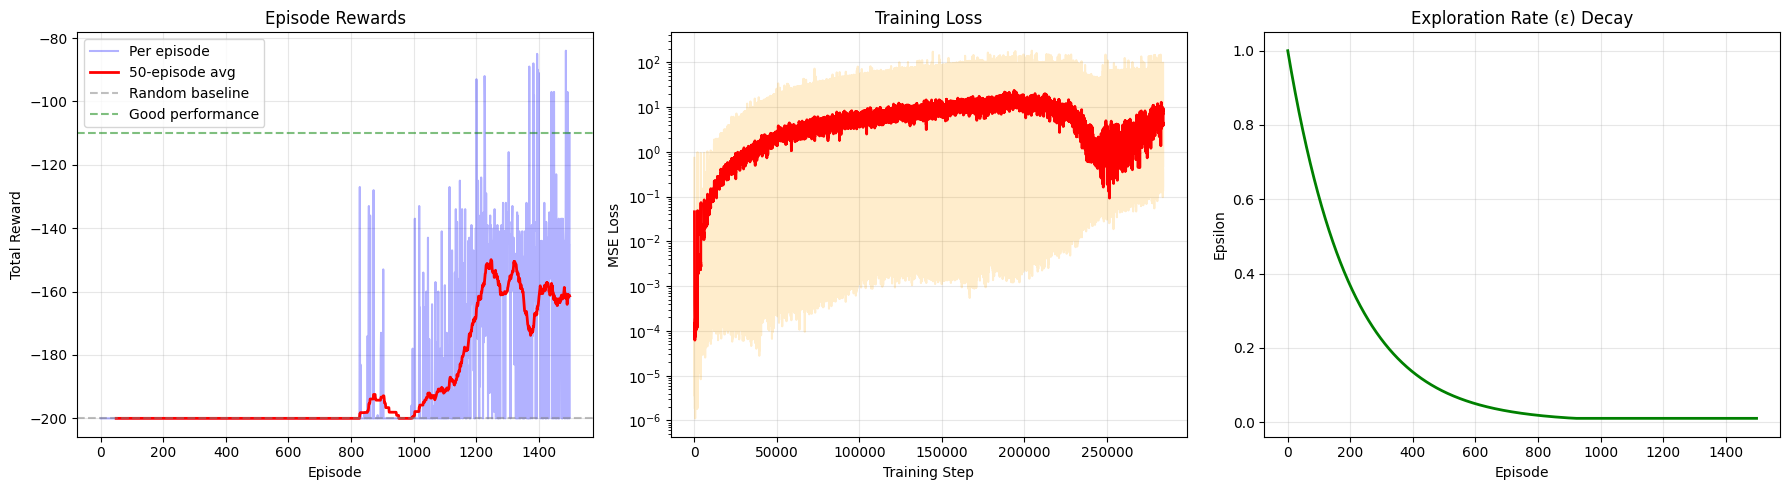

In [27]:
# ============================================================
# Cell: Training Curves Visualization
# Purpose: Plot episode rewards, training loss, and epsilon
#          decay to analyze the training dynamics.
# ============================================================

def plot_training_results(rewards, losses, epsilon_start=1.0, epsilon_end=0.01,
                          epsilon_decay=0.995, n_episodes=1000, window=50):
    """Plot comprehensive training diagnostics."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # --- Plot 1: Episode Rewards ---
    ax = axes[0]
    ax.plot(rewards, alpha=0.3, color='blue', label='Per episode')
    # Moving average
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), moving_avg, color='red',
                linewidth=2, label=f'{window}-episode avg')
    ax.axhline(y=-200, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
    ax.axhline(y=-110, color='green', linestyle='--', alpha=0.5, label='Good performance')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Total Reward')
    ax.set_title('Episode Rewards')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # --- Plot 2: Training Loss ---
    ax = axes[1]
    if losses:
        ax.plot(losses, alpha=0.2, color='orange')
        if len(losses) >= 100:
            loss_avg = np.convolve(losses, np.ones(100)/100, mode='valid')
            ax.plot(range(99, len(losses)), loss_avg, color='red', linewidth=2)
        ax.set_xlabel('Training Step')
        ax.set_ylabel('MSE Loss')
        ax.set_title('Training Loss')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    
    # --- Plot 3: Epsilon Decay ---
    ax = axes[2]
    epsilons = [max(epsilon_end, epsilon_start * (epsilon_decay ** i)) for i in range(n_episodes)]
    ax.plot(epsilons, color='green', linewidth=2)
    ax.set_xlabel('Episode')
    ax.set_ylabel('Epsilon')
    ax.set_title('Exploration Rate (ε) Decay')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_results(
    rewards=episode_rewards,
    losses=agent.training_losses,
    n_episodes=len(episode_rewards),
)


## Evaluating the Trained Agent

During training, performance is affected by exploration ($\epsilon$-greedy). To properly assess the learned policy, we evaluate with $\epsilon = 0$ (purely greedy actions).


In [28]:
# ============================================================
# Cell: Evaluation
# Purpose: Evaluate the trained agent using a purely greedy
#          policy (no exploration) over multiple episodes.
# ============================================================

def evaluate_agent(env, agent, n_episodes=50, seed=0):
    """Evaluate agent with greedy policy (epsilon=0)."""
    rewards = []
    steps_list = []
    successes = 0
    
    for ep in range(n_episodes):
        state, _ = env.reset(seed=seed + ep)
        total_reward = 0
        steps = 0
        done = False
        
        while not done:
            action = agent.select_action(state, training=False)  # greedy
            state, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1
            done = terminated or truncated
            
            if terminated:  # reached the goal
                successes += 1
        
        rewards.append(total_reward)
        steps_list.append(steps)
    
    return rewards, steps_list, successes

eval_rewards, eval_steps, n_successes = evaluate_agent(env, agent, n_episodes=50)

print("=" * 50)
print("EVALUATION RESULTS (50 episodes, greedy policy)")
print("=" * 50)
print(f"  Mean reward:   {np.mean(eval_rewards):.1f} ± {np.std(eval_rewards):.1f}")
print(f"  Mean steps:    {np.mean(eval_steps):.1f} ± {np.std(eval_steps):.1f}")
print(f"  Success rate:  {n_successes}/50 ({100*n_successes/50:.0f}%)")
print(f"  Best reward:   {np.max(eval_rewards):.1f}")
print(f"  Worst reward:  {np.min(eval_rewards):.1f}")


EVALUATION RESULTS (50 episodes, greedy policy)
  Mean reward:   -135.2 ± 31.9
  Mean steps:    135.2 ± 31.9
  Success rate:  48/50 (96%)
  Best reward:   -85.0
  Worst reward:  -200.0


PHYSICS SENSITIVITY EVALUATION (50 episodes each)
Scenario              MeanR     StdR  MeanSteps  Success%   Physics
----------------------------------------------------------------------------------------------------
baseline             -133.6     31.5      133.6     94.0%   {}
gravity_1            -133.6     31.5      133.6     94.0%   {'gravity': 0.0025}
gravity_2            -158.1     36.4      158.1     60.0%   {'gravity': 0.00375}
gravity_3            -181.9     31.4      181.9     26.0%   {'gravity': 0.005}
gravity_4            -200.0      0.0      200.0      0.0%   {'gravity': 0.00625}
gravity_5            -200.0      0.0      200.0      0.0%   {'gravity': 0.0075}
gravity_6            -200.0      0.0      200.0      0.0%   {'gravity': 0.00875}
gravity_7            -200.0      0.0      200.0      0.0%   {'gravity': 0.01}
gravity_8            -200.0      0.0      200.0      0.0%   {'gravity': 0.011250000000000001}
gravity_9            -200.0      0.0      200.0      0.0%   {'gr

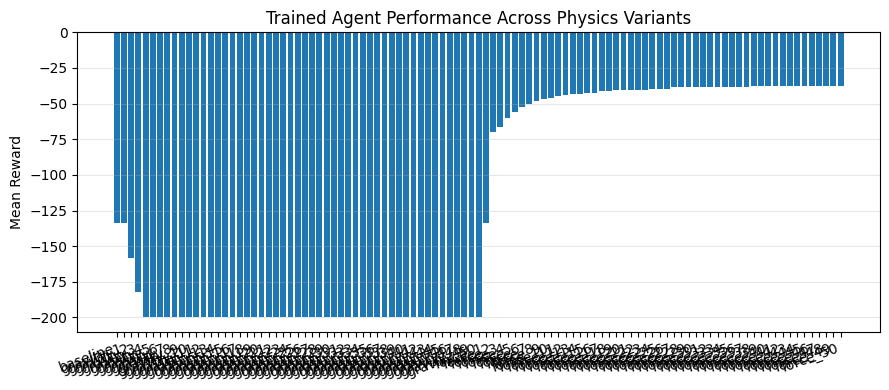

In [ ]:
# ============================================================
# Cell: Physics Sensitivity Evaluation
# Purpose: Evaluate the trained MountainCar agent on the same
#          environment with different physics parameters.
#          Edit PHYSICS_SCENARIOS to run your own variants.
# ============================================================

# Easy-to-edit scenarios:
# - Keys are scenario names.
# - Values are MountainCar physics attributes on env.unwrapped.
# Common knobs: force, gravity, max_speed, goal_position
PHYSICS_SCENARIOS = {
    "baseline": {},
    "g1": {"gravity": 0.0002},
    "g2": {"gravity": 0.0005},
    "g3": {"gravity": 0.0010},
    "g4": {"gravity": 0.0015},
    "g5": {"gravity": 0.0025},
    "g6": {"gravity": 0.004},
    "g7": {"gravity": 0.005},
    "g8": {"gravity": 0.006},
    "g9": {"gravity": 0.007},
    "g10": {"gravity": 0.008}
}

DEFAULT_GRAVITY = 0.0025
DEFAULT_FORCE = 0.001

PHYSICS_SCENARIOS = {"baseline": {}}

# 50 gravity-only scenarios
gravity_step = DEFAULT_GRAVITY / 2
for i in range(50):
    PHYSICS_SCENARIOS[f"gravity_{i+1}"] = {
        "gravity": DEFAULT_GRAVITY + i * gravity_step
    }

# 50 force-only scenarios
force_step = DEFAULT_FORCE / 2
for i in range(50):
    PHYSICS_SCENARIOS[f"force_{i+1}"] = {
        "force": DEFAULT_FORCE - i * force_step
    }

N_EVAL_EPISODES = 50
BASE_SEED = SEED

def make_mountaincar_env_with_physics(physics_params: dict, base_seed: int):
    e = gym.make("MountainCar-v0")
    u = e.unwrapped

    for param_name, param_value in physics_params.items():
        if not hasattr(u, param_name):
            raise AttributeError(
                f"MountainCarEnv has no attribute '{param_name}'. "
                "Check PHYSICS_SCENARIOS keys."
            )
        setattr(u, param_name, param_value)

    # Ensure deterministic reset behavior for fair scenario comparison.
    e.reset(seed=base_seed)
    return e


def evaluate_agent_across_physics(agent, scenarios: dict, n_episodes: int = 50, seed: int = 0):
    rows = []

    for scenario_name, physics_params in scenarios.items():
        test_env = make_mountaincar_env_with_physics(physics_params, base_seed=seed)
        rewards, steps, successes = evaluate_agent(
            env=test_env,
            agent=agent,
            n_episodes=n_episodes,
            seed=seed,
        )

        rows.append(
            {
                "scenario": scenario_name,
                "params": physics_params,
                "mean_reward": float(np.mean(rewards)),
                "std_reward": float(np.std(rewards)),
                "mean_steps": float(np.mean(steps)),
                "success_rate": float(successes / n_episodes),
            }
        )

        test_env.close()

    return rows


physics_results = evaluate_agent_across_physics(
    agent=agent,
    scenarios=PHYSICS_SCENARIOS,
    n_episodes=N_EVAL_EPISODES,
    seed=BASE_SEED,
)

print("=" * 100)
print(f"PHYSICS SENSITIVITY EVALUATION ({N_EVAL_EPISODES} episodes each)")
print("=" * 100)
print(f"{'Scenario':<18} {'MeanR':>8} {'StdR':>8} {'MeanSteps':>10} {'Success%':>9}   Physics")
print("-" * 100)

for row in physics_results:
    print(
        f"{row['scenario']:<18} "
        f"{row['mean_reward']:>8.1f} "
        f"{row['std_reward']:>8.1f} "
        f"{row['mean_steps']:>10.1f} "
        f"{100*row['success_rate']:>8.1f}%   "
        f"{row['params']}"
    )

# Optional: quick bar chart for mean reward
plt.figure(figsize=(9, 4))
labels = [r['scenario'] for r in physics_results]
means = [r['mean_reward'] for r in physics_results]
plt.bar(labels, means)
plt.xticks(rotation=20, ha='right')
plt.ylabel('Mean Reward')
plt.title('Trained Agent Performance Across Physics Variants')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Visualizing the Learned Value Function

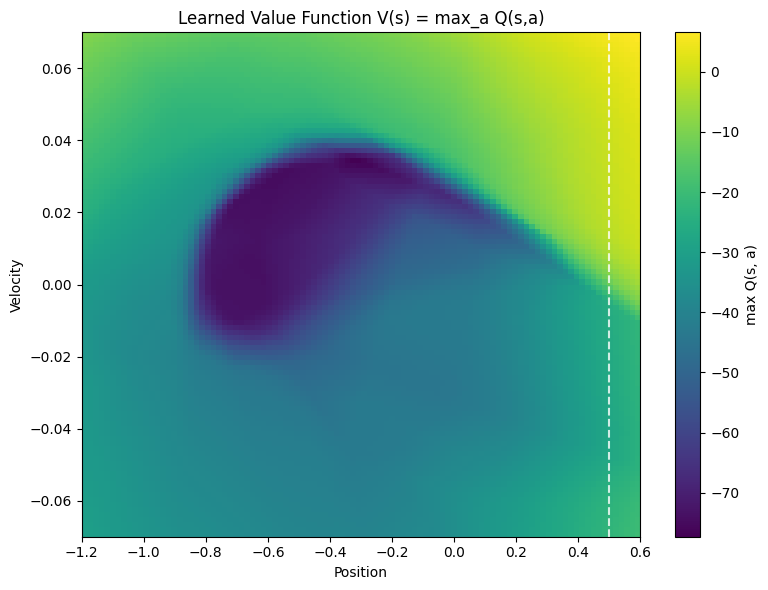

Interpretation:
States near the goal have higher value; states at the
  bottom of the valley have lower value (further from the goal).


In [12]:

def visualize_values(agent, resolution=100):
    positions = np.linspace(-1.2, 0.6, resolution)
    velocities = np.linspace(-0.07, 0.07, resolution)
    value_grid = np.zeros((resolution, resolution))
    
    for i, vel in enumerate(velocities):
        for j, pos in enumerate(positions):
            state = torch.FloatTensor([pos, vel]).unsqueeze(0).to(DEVICE)
            with torch.no_grad():
                q_values = agent.policy_net(state)
            value_grid[i, j] = q_values.max(dim=1)[0].item()

    # --- Value Function Heatmap ---
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(value_grid, extent=[-1.2, 0.6, -0.07, 0.07],
                   aspect='auto', origin='lower', cmap='viridis')
    plt.colorbar(im, ax=ax, label='max Q(s, a)')
    ax.set_xlabel('Position')
    ax.set_ylabel('Velocity')
    ax.set_title('Learned Value Function V(s) = max_a Q(s,a)')
    ax.axvline(x=0.5, color='white', linestyle='--', alpha=0.8)
    plt.tight_layout()
    plt.show()

visualize_values(agent)

print("Interpretation:")
print("States near the goal have higher value; states at the")
print("  bottom of the valley have lower value (further from the goal).")


### Visualizing Agent Trajectories

Let's watch the trained agent navigate the mountain by plotting its trajectory in the state space and on the terrain.


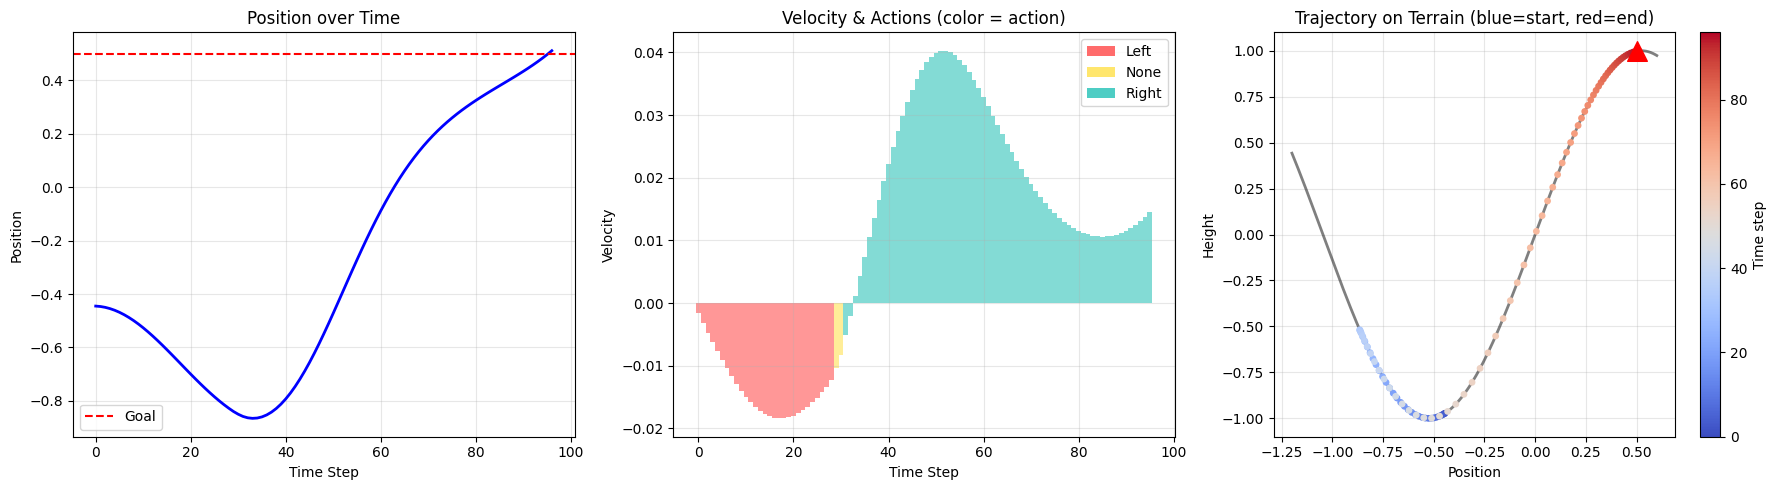

Episode length: 96 steps
Final position: 0.5113
Reached goal: True


In [13]:
# ============================================================
# Cell: Trajectory Visualization
# Purpose: Record and plot a single episode trajectory to
#          visualize the swing-back-and-forth strategy.
# ============================================================

def record_episode(env, agent, seed=42):
    """Record a full episode trajectory."""
    state, _ = env.reset(seed=seed)
    trajectory = {'positions': [state[0]], 'velocities': [state[1]], 'actions': []}
    done = False
    
    while not done:
        action = agent.select_action(state, training=False)
        state, reward, terminated, truncated, _ = env.step(action)
        trajectory['positions'].append(state[0])
        trajectory['velocities'].append(state[1])
        trajectory['actions'].append(action)
        done = terminated or truncated
    
    return trajectory

traj = record_episode(env, agent)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Plot 1: Position over time ---
ax = axes[0]
ax.plot(traj['positions'], linewidth=2, color='blue')
ax.axhline(y=0.5, color='red', linestyle='--', label='Goal')
ax.set_xlabel('Time Step')
ax.set_ylabel('Position')
ax.set_title('Position over Time')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Velocity over time ---
ax = axes[1]
colors_map = {0: '#FF6B6B', 1: '#FFE66D', 2: '#4ECDC4'}
action_labels = {0: 'Left', 1: 'None', 2: 'Right'}
for i in range(len(traj['actions'])):
    ax.bar(i, traj['velocities'][i+1], color=colors_map[traj['actions'][i]],
           width=1.0, alpha=0.7)
ax.set_xlabel('Time Step')
ax.set_ylabel('Velocity')
ax.set_title('Velocity & Actions (color = action)')
# Custom legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors_map[a], label=action_labels[a]) for a in [0,1,2]]
ax.legend(handles=legend_elements)
ax.grid(True, alpha=0.3)

# --- Plot 3: Trajectory on terrain ---
ax = axes[2]
x = np.linspace(-1.2, 0.6, 300)
ax.plot(x, np.sin(3 * x), 'k-', linewidth=2, alpha=0.5)
positions = np.array(traj['positions'])
heights = np.sin(3 * positions)
scatter = ax.scatter(positions, heights, c=range(len(positions)),
                     cmap='coolwarm', s=15, zorder=3)
ax.scatter([0.5], [np.sin(1.5)], color='red', s=200, marker='^', zorder=5)
ax.set_xlabel('Position')
ax.set_ylabel('Height')
ax.set_title('Trajectory on Terrain (blue=start, red=end)')
plt.colorbar(scatter, ax=ax, label='Time step')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Episode length: {len(traj['actions'])} steps")
print(f"Final position: {traj['positions'][-1]:.4f}")
print(f"Reached goal: {traj['positions'][-1] >= 0.5}")


In [14]:
# ============================================================
# Cell: Visualize Trained Agent Behaviour
# Purpose: Record and display one episode of the trained agent.
# ============================================================

def record_episode_frames(env_name, agent, seed=SEED, max_steps=200):
    """
    Record rendered frames from one episode using a trained agent (greedy policy).

    Returns:
        frames: list of RGB arrays
        traj: dict with positions, velocities, actions (matches your notation)
    """
    rec_env = gym.make(env_name, render_mode="rgb_array")
    state, _ = rec_env.reset(seed=seed)

    frames = [rec_env.render()]
    traj = {"positions": [state[0]], "velocities": [state[1]], "actions": []}

    done = False
    steps = 0

    while not done and steps < max_steps:
        # Greedy action (no exploration)
        action = agent.select_action(state, training=False)

        state, reward, terminated, truncated, _ = rec_env.step(action)
        done = terminated or truncated

        frames.append(rec_env.render())

        traj["positions"].append(state[0])
        traj["velocities"].append(state[1])
        traj["actions"].append(action)

        steps += 1

    rec_env.close()
    return frames, traj


# Record one episode with the trained agent
frames, traj = record_episode_frames("MountainCar-v0", agent, seed=SEED)

# Animate the frames (same as your random agent visualization)
fig, ax = plt.subplots(figsize=(6, 4))
ax.axis("off")
img = ax.imshow(frames[0])

def update(frame):
    img.set_data(frame)
    return [img]

ani = animation.FuncAnimation(fig, update, frames=frames, interval=20, blit=True)
plt.close(fig)
HTML(ani.to_jshtml())

## Experiments & Ablation Studies

A key part of understanding RL algorithms is systematically varying components and observing the effects. Below are several experiments you should run. For each experiment, **train a new agent** with the specified modification and compare against the baseline.

> **Important:** For fair comparisons, always use the same random seed and number of episodes.

### Experiment Helper

The following cell provides a helper function that runs an experiment with custom hyperparameters and returns the training curve.


In [16]:
# ============================================================
# Cell: Experiment Helper
# Purpose: Utility function to train an agent with custom
#          hyperparameters and return the learning curve.
# ============================================================

def run_experiment(
    label: str,
    n_episodes: int = 600,
    hidden_dim: int = 128,
    lr: float = 1e-3,
    gamma: float = 0.99,
    epsilon_start: float = 1.0,
    epsilon_end: float = 0.01,
    epsilon_decay: float = 0.995,
    buffer_capacity: int = 10000,
    batch_size: int = 64,
    target_update_freq: int = 10,
    seed: int = SEED,
):
    """Train a DQN agent with given hyperparameters and return rewards."""
    env_exp = gym.make("MountainCar-v0")
    
    # Reset seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    
    agent_exp = DQNAgent(
        state_dim=2, n_actions=3,
        hidden_dim=hidden_dim, lr=lr, gamma=gamma,
        epsilon_start=epsilon_start, epsilon_end=epsilon_end,
        epsilon_decay=epsilon_decay,
        buffer_capacity=buffer_capacity, batch_size=batch_size,
        target_update_freq=target_update_freq,
    )
    
    rewards = train_dqn(env_exp, agent_exp, n_episodes=n_episodes,
                        verbose_every=n_episodes + 1, seed=seed)  # suppress output
    env_exp.close()
    
    print(f"  [{label}] Final avg (last 100): {np.mean(rewards[-100:]):.1f}")
    return rewards

def plot_experiments(results: dict, title: str, window: int = 50):
    """Plot multiple experiment learning curves on the same axes."""
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for label, rewards in results.items():
        if len(rewards) >= window:
            smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
            ax.plot(range(window-1, len(rewards)), smoothed, linewidth=2, label=label)
    
    ax.axhline(y=-200, color='gray', linestyle='--', alpha=0.5, label='Random baseline')
    ax.set_xlabel('Episode', fontsize=12)
    ax.set_ylabel(f'Reward ({window}-ep moving avg)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()



### Experiment 1: Effect of Replay Buffer Size

The replay buffer size determines how much past experience the agent retains. A very small buffer means the agent only learns from very recent transitions (highly correlated). A very large buffer may include a lot of stale, suboptimal experience.

**Run this experiment** to see how buffer size affects learning:


Experiment 1: Replay Buffer Size
  [Buffer=500] Final avg (last 100): -114.5
  [Buffer=5000] Final avg (last 100): -127.5
  [Buffer=10000] Final avg (last 100): -135.5
  [Buffer=50000] Final avg (last 100): -136.9


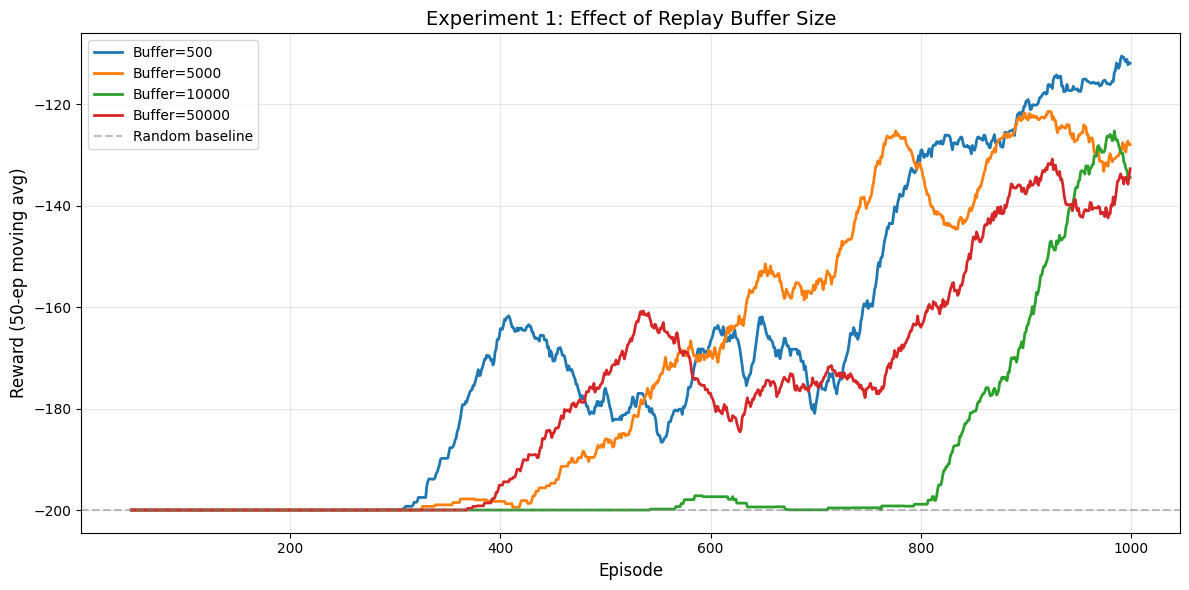

In [ ]:
# ============================================================
# Cell: Experiment 1 — Replay Buffer Size Ablation
# Purpose: Compare learning with different buffer capacities.
# ============================================================

print("Experiment 1: Replay Buffer Size")
print("=" * 50)

results_buffer = {}
for buf_size in [500, 5000, 10000, 50000]:
    label = f"Buffer={buf_size}"
    results_buffer[label] = run_experiment(label=label, buffer_capacity=buf_size, n_episodes=1000)

plot_experiments(results_buffer, "Experiment 1: Effect of Replay Buffer Size")


### Experiment 2: Effect of Learning Rate

The learning rate controls how much the network weights change per gradient step. Too high and training is unstable; too low and learning is painfully slow.


Experiment 2: Learning Rate
  [lr=0.0001] Final avg (last 100): -168.3
  [lr=0.0005] Final avg (last 100): -151.5
  [lr=0.001] Final avg (last 100): -135.5
  [lr=0.005] Final avg (last 100): -168.7


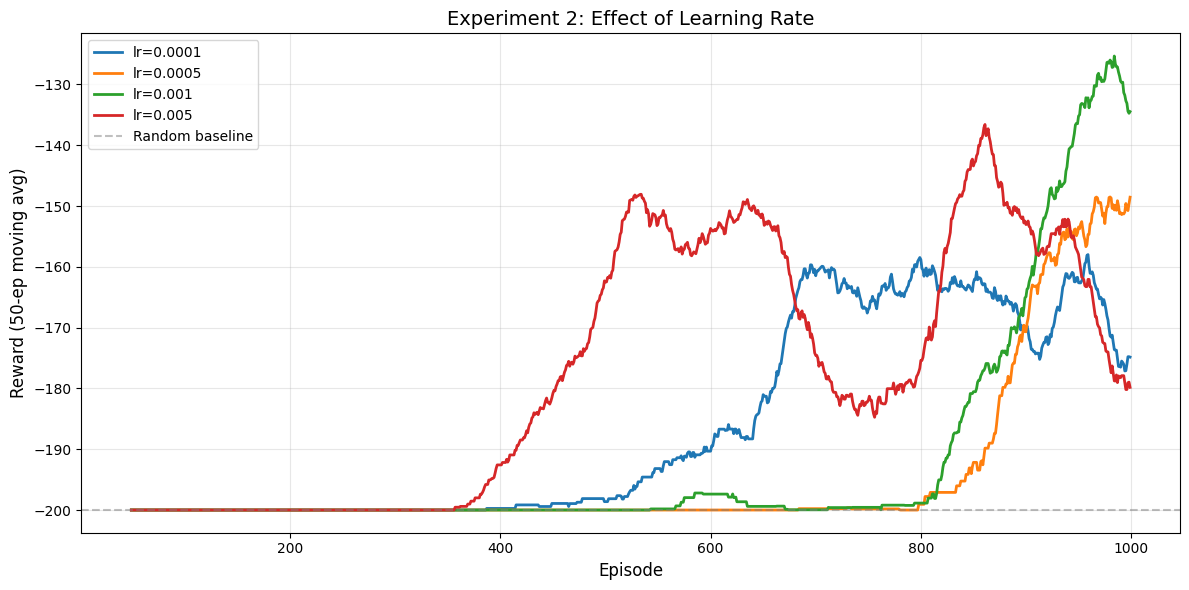

In [ ]:
# ============================================================
# Cell: Experiment 2 — Learning Rate Ablation
# Purpose: Compare learning with different learning rates.
# ============================================================

print("Experiment 2: Learning Rate")
print("=" * 50)

results_lr = {}
for lr in [1e-4, 5e-4, 1e-3, 5e-3]:
    label = f"lr={lr}"
    results_lr[label] = run_experiment(label=label, lr=lr, n_episodes=1000)

plot_experiments(results_lr, "Experiment 2: Effect of Learning Rate")


### Experiment 3: Effect of Exploration Schedule (Epsilon Decay)

The epsilon decay rate determines how quickly the agent transitions from exploring to exploiting. Fast decay may cause the agent to commit to a bad policy too early; slow decay wastes time on random actions.


Experiment 3: Epsilon Decay Rate
  [ε-decay=0.99] Final avg (last 100): -149.7
  [ε-decay=0.995] Final avg (last 100): -135.5
  [ε-decay=0.999] Final avg (last 100): -189.5
  [ε-decay=0.9999] Final avg (last 100): -200.0


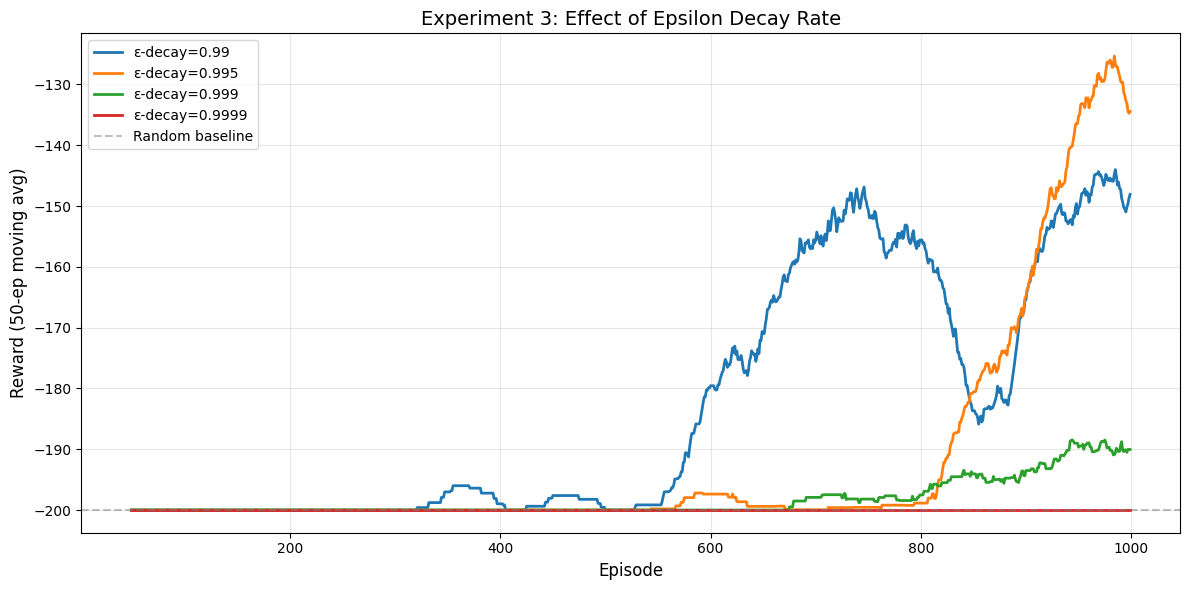

In [ ]:
# ============================================================
# Cell: Experiment 3 — Epsilon Decay Ablation
# Purpose: Compare different exploration schedules.
# ============================================================

print("Experiment 3: Epsilon Decay Rate")
print("=" * 50)

results_eps = {}
for decay in [0.99, 0.995, 0.999, 0.9999]:
    label = f"ε-decay={decay}"
    results_eps[label] = run_experiment(label=label, epsilon_decay=decay, n_episodes=1000)

plot_experiments(results_eps, "Experiment 3: Effect of Epsilon Decay Rate")


### Experiment 4: Target Network Update Frequency

How often should we sync the target network with the policy network? More frequent updates mean the target tracks the policy more closely (possibly less stable). Less frequent updates provide more stable targets but may slow learning.


Experiment 4: Target Network Update Frequency
  [Target update=1 eps] Final avg (last 100): -107.0
  [Target update=5 eps] Final avg (last 100): -155.3
  [Target update=10 eps] Final avg (last 100): -135.5
  [Target update=50 eps] Final avg (last 100): -199.6


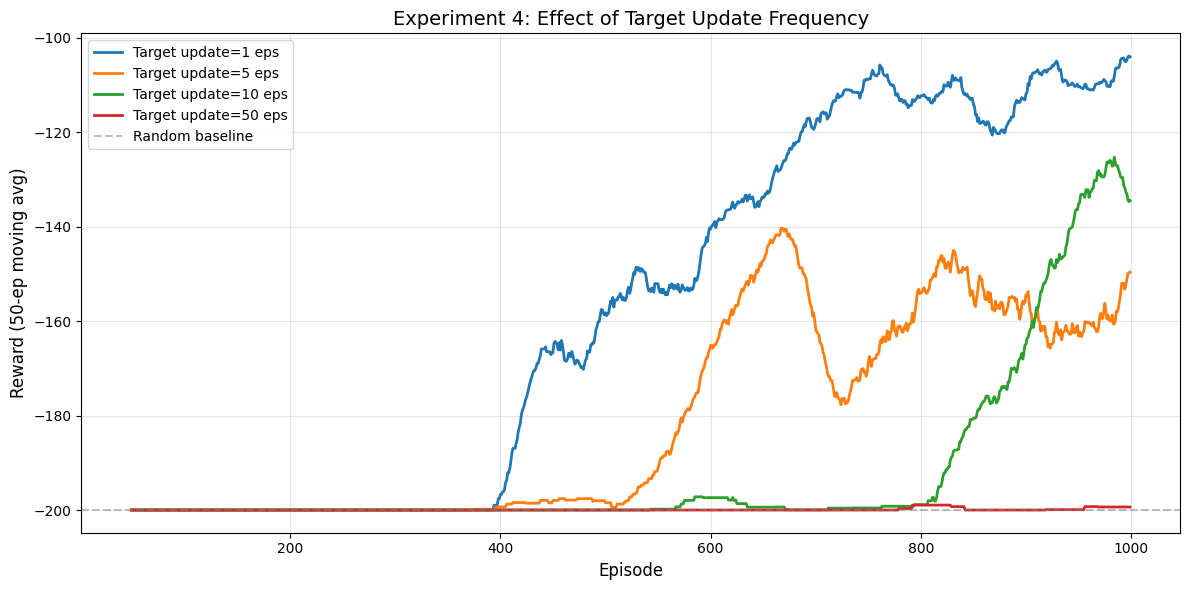

In [ ]:
# ============================================================
# Cell: Experiment 4 — Target Update Frequency Ablation
# Purpose: Compare different target network update intervals.
# ============================================================

print("Experiment 4: Target Network Update Frequency")
print("=" * 50)

results_target = {}
for freq in [1, 5, 10, 50]:
    label = f"Target update={freq} eps"
    results_target[label] = run_experiment(label=label, target_update_freq=freq, n_episodes=1000)

plot_experiments(results_target, "Experiment 4: Effect of Target Update Frequency")


### Experiment 5: Effect of Discount Factor ($\gamma$)

The discount factor determines how much the agent values future rewards versus immediate rewards. In Mountain Car, the agent must plan many steps ahead (swing left before going right), so $\gamma$ should be high.


Experiment 5: Discount Factor (gamma)
  [γ=0.9] Final avg (last 100): -197.8
  [γ=0.95] Final avg (last 100): -184.8
  [γ=0.99] Final avg (last 100): -135.5
  [γ=0.999] Final avg (last 100): -197.1


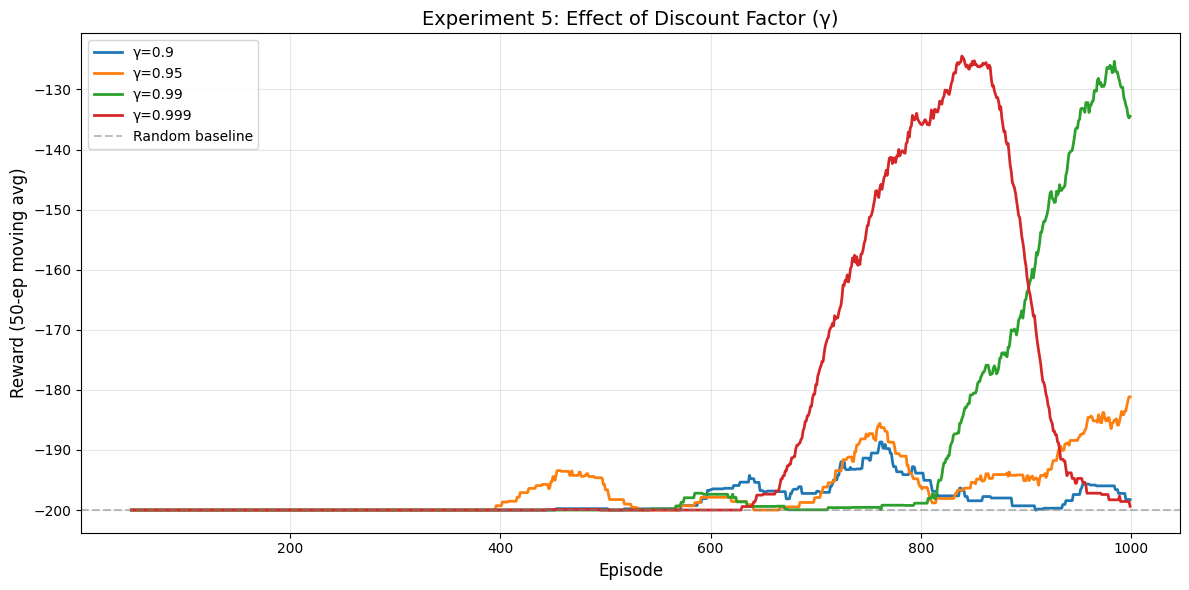

In [ ]:
# ============================================================
# Cell: Experiment 5 — Discount Factor Ablation
# Purpose: Compare different values of gamma.
# ============================================================

print("Experiment 5: Discount Factor (gamma)")
print("=" * 50)

results_gamma = {}
for g in [0.9, 0.95, 0.99, 0.999]:
    label = f"γ={g}"
    results_gamma[label] = run_experiment(label=label, gamma=g, n_episodes=1000)

plot_experiments(results_gamma, "Experiment 5: Effect of Discount Factor (γ)")


### Experiment 6: Effect of Network Size

Does a bigger network always mean better performance? Let's find out.


Experiment 6: Network Hidden Dimension
  [Hidden=32] Final avg (last 100): -200.0
  [Hidden=64] Final avg (last 100): -177.0
  [Hidden=128] Final avg (last 100): -135.5
  [Hidden=256] Final avg (last 100): -174.4


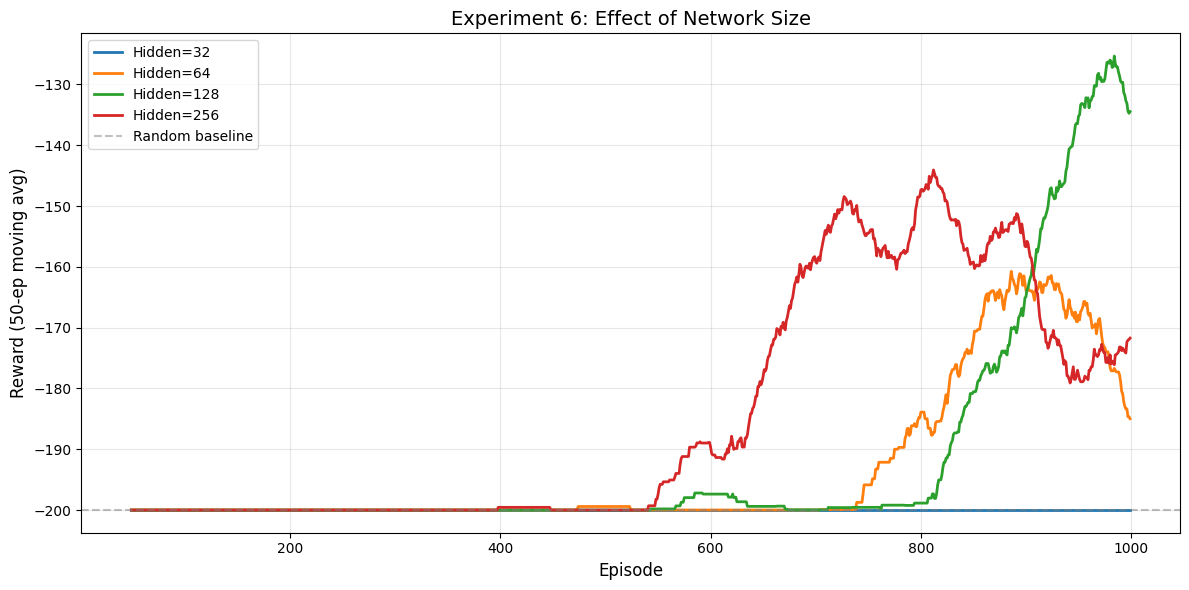

In [ ]:
# ============================================================
# Cell: Experiment 6 — Network Architecture Ablation
# Purpose: Compare networks of different sizes.
# ============================================================

print("Experiment 6: Network Hidden Dimension")
print("=" * 50)

results_arch = {}
for h_dim in [32, 64, 128, 256]:
    label = f"Hidden={h_dim}"
    results_arch[label] = run_experiment(label=label, hidden_dim=h_dim, n_episodes=1000)

plot_experiments(results_arch, "Experiment 6: Effect of Network Size")


## TO DO: Discussion Questions

Answer the following questions in detail. Support your answers with evidence from your experiments.


**Q1.** Explain the "deadly triad" in reinforcement learning (function approximation + bootstrapping + off-policy learning). Which of these are present in DQN, and how does DQN mitigate the associated instabilities?

The deadly triad is function approximation + bootstrapping + off-policy learning, which together can cause divergence. DQN has all three as it uses a neural network for Q(s,a), it bootstraps with targets of the form y = r + gamma * max_a' Q_target(s',a'), and it learns off policy through replay data generated by older epsilon-greedy policies. This can be unstable because the data generating policy and our main policy can be vastly different, causing learning signals to not be representative for our main policy. Our target-update experiment  shows that when the target was updated very infrequently (every 50 episodes), learning failed and rewards stayed near -200, while frequent updates (every 1 episode) learned much faster and reached around -110. 

**Q2.** The replay buffer samples transitions uniformly at random. Could we do better? Research **Prioritized Experience Replay (PER)** and explain how it modifies the sampling distribution. What problem does it solve, and what new problem does it introduce?

PER changes the sampling distribution so that transitions with larger TD error are sampled more often. Uniform replay treats all transitions equally, but in our buffer-size experiment we see that large buffers like 50000 slows learning compared to a smaller buffer (like 500), which learns faster. This suggests that not all transitions are equally useful as newer ones contain more relevant signals. PER addresses this by making us focus updates on more informative transitions. The problem it introduces is that sampling becomes biased, so data is no longer iid. So PER introduces importance-sampling corrections to reduce this bias through extra hyperparameters, which means more tuning.


**Q3.** State your observation on Ablation Experiments: Buffer Size, Learning Rate, Epsilon Decay, Discount Factor, Target Update Frequency, and Network Size, and use concepts learnt to explain/justify your observations, does it makes sense, works as you expected, why you see what you see. 

For buffer size, a small buffer (500) improved earlier and reached higher reward than very large buffers (50000), which learned more slowly. This suggests that too much old experience can slow learning. For learning rate, 0.001 performed best, while 0.0001 learned too slowly and 0.005 was unstable, showing how step size controls convergence rate. For epsilon decay, 0.995 worked best. very slow decay (0.9999) stayed near -200 because the agent remained random too long, while faster decay (0.99) reduced exploration and plateaued lower. For target update frequency, very infrequent updates (50 episodes) failed completely, while frequent updates (1 episode) learned fastest, showing the effect of stale/old targets. For discount factor, gamma = 0.99  outperformed 0.9 and 0.95, which stayed near -200 longer, indicating that MountainCar requires longer-horizon credit assignment. however gamma = 0.999 seems to cause instability. For network size, hidden size 128 performed best, while 32 underfit and 256 was less stable, showing that too little capacity cannot represent the value function and too much capacity can overfit.

**Q4.** DQN uses a fixed target network that is periodically updated with a hard copy. An alternative is **soft updates** (Polyak averaging): theta- <- tau theta + (1-tau)theta- with small tau. What are the advantages and disadvantages of each approach?

Hard updates are simple but can create stale targets. Our experiment shows that when updates are too infrequent, learning collapses. Soft updates would instead move the target gradually, reducing abrupt jumps and  smoothing training. The disadvantage is the addition of another hyperparameter (tau) to finetune. If tau is too small then tracking becomes very slow, causing slower convergence.

**Q5.** If you increased the maximum episode length from 200 to 500 steps, how would you expect the training dynamics to change? Would the agent learn faster or slower? Why?

The results show that the parameters are very sensitive and even small changes can collapse or worsen performance. This is because longer episodes mean the agent spends more time accumulating negative rewards before reset, slowing down useful learning signals. It also increases the effective horizon, making bootstrapped targets more variable and harder to fit. Since stability was already sensitive to gamma and target updates, extending the horizon would likely increase instability and new finetuning to maintain performance.

---


## Atari Breakout

In Breakout the agent controls a paddle at the bottom of the screen and must bounce a ball to destroy
rows of bricks at the top. The agent receives a reward for each brick it destroys.

**Key environment details** ([ALE docs](https://ale.farama.org/environments/breakout/)):

| Property | Details |
|---|---|
| **Actions** | `0`: NOOP, `1`: FIRE (launch ball), `2`: RIGHT, `3`: LEFT |
| **Observation** | 210 × 160 RGB frame (preprocessed to 84 × 84 grayscale) |
| **Reward** | +1 to +7 per brick destroyed (depending on row) |
| **Lives** | 5 per game; losing all lives ends the episode |
| **State representation** | We stack 2 consecutive frames to capture ball motion |

### Differences from Mountain Car

This time around, we will implement **soft updates** (Polyak averaging) instead of hard copying the target network. Soft updates gradually blend the current policy network weights into the target network, reducing variance and improving training stability. Instead of $\theta^- \leftarrow \theta$ every $C$ episodes, we use:
$$\theta^- \leftarrow \tau \theta + (1-\tau) \theta^-$$
where $\tau$ is a small coefficient (typically 0.001). This approach encourages smoother updates and more stable learning dynamics.

### DQN Architecture for Pixel-Based Input

Since we are dealing with pixel images rather than low-dimensional state vectors, a Convolutional Neural Network (CNN) is a much better choice than a fully connected network. CNNs naturally exploit the spatial structure of images and can learn hierarchical visual features.
Our DQN network architecture will consist of:

Convolutional layers to extract spatial features from the 42 × 42 grayscale images:

Conv2d(in_channels=2, out_channels=16, kernel_size=6, stride=3) → ReLU → Output: 16 × 13 × 13
Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2) → ReLU → Output: 32 × 5 × 5


Flattening layer to convert the 2D feature maps into a 1D vector.
Fully connected layers for Q-value estimation:

Linear(in_features=32×5×5=800, out_features=256) → ReLU
Linear(in_features=256, out_features=num_actions)



Note: The standard DeepMind DQN uses 3 convolutional layers on 84×84 input. We use 2 layers because our frames are downscaled to 42×42 — the spatial dimensions shrink too quickly for a third layer to be useful (we're already at 5×5 after two layers). This smaller architecture also trains faster!

**Why CNN?**
- **Spatial locality:** CNNs respect the spatial structure of images, capturing local patterns (edges, objects, etc.).
- **Parameter efficiency:** Weight sharing in convolutional layers reduces the number of trainable parameters compared to a fully connected network applied to 84×84 or reduced size 42×42 images.
- **Feature hierarchy:** Early layers learn low-level features (edges), middle layers learn mid-level features (object parts), and deep layers learn high-level features (objects, actions).
- **Translation invariance:** CNNs are robust to small translations in the image, which is important for Atari games where sprites move smoothly.

In [17]:
# ============================================================
# Cell: Breakout Helpers
# Purpose: Utility functions for Atari preprocessing, seeding,
#          video recording, and epsilon scheduling.
# Check out this cell to understand the differences between 
# this env and the previous one and changes in design choices
# one needs to make in order to make the same algorithm work
# in a different env
# ============================================================

# Use GPU/MPS for Breakout (actual GPU workload), fall back to CPU
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print(f"Breakout will use device: {DEVICE}")

# ---------- Constants ----------
FRAME_SIZE = 42          # Downscaled frame resolution (42×42 instead of 84×84)
FRAME_STACK = 2          # Number of stacked frames (captures motion)
N_ACTIONS = 4            # NOOP, FIRE, RIGHT, LEFT
MAX_TIMESTEPS = 500_000  # Reduced from 2M — enough to see learning

def seed_everything(seed=SEED):
    """Seed all RNGs for reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def make_breakout_env(render_mode=None, seed=SEED):
    """
    Create a preprocessed Breakout environment.
    
    Key preprocessing:
    - Grayscale conversion (3 channels → 1)
    - Frame skip = 4 (repeat action for 4 frames, return max of last 2)
    - Resize to 42×42 (instead of 84×84 — 4x fewer pixels!)
    - No observation scaling (keep uint8 for memory efficiency)
    """
    try:
        env = gym.make(
            "ALE/Breakout-v5",
            render_mode=render_mode,
            repeat_action_probability=0.0,  # deterministic
            frameskip=1,                    # disable built-in skip
        )
        preprocessing_frame_skip = 4
    except TypeError:
        env = gym.make(
            "ALE/Breakout-v5",
            render_mode=render_mode,
            repeat_action_probability=0.0,
        )
        preprocessing_frame_skip = 1

    env.reset(seed=seed)
    env = AtariPreprocessing(
        env,
        grayscale_obs=True,
        screen_size=FRAME_SIZE,        # 42×42 instead of 84×84
        frame_skip=preprocessing_frame_skip,
        scale_obs=False,
    )
    return env

def epsilon_gen(start=1.0, decay=0.9995, minimum=0.01):
    """Generator that yields exponentially decaying epsilon values."""
    eps = start
    while True:
        yield eps
        eps = max(minimum, eps * decay)

print(f"Frame size: {FRAME_SIZE}×{FRAME_SIZE}")
print(f"Frame stack: {FRAME_STACK}")
print(f"Max timesteps: {MAX_TIMESTEPS:,}")


Breakout will use device: mps
Frame size: 42×42
Frame stack: 2
Max timesteps: 500,000


## Replay Buffer
**Fill in TO DO**

In [18]:
# ============================================================
# Cell: Replay Buffer (Breakout)
# ============================================================

Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))

class ReplayBuffer:
    """
    Fixed-size replay buffer for Breakout.
    
    States are stored as uint8 numpy arrays to save memory
    (42×42×2 frames = ~3.5 KB per transition vs ~14 KB at 84×84).
    """
    
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        """Store a single transition."""
        # Store states as uint8 to save memory
        self.buffer.append(Transition(
            np.array(state, dtype=np.uint8),
            action,
            reward,
            np.array(next_state, dtype=np.uint8),
            done,
        ))
    
    def sample(self, batch_size):
        """Sample a random mini-batch, returned as tensors on DEVICE."""
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        
        # Convert to float32 and normalize pixels to [0, 1]
        states      = torch.FloatTensor(np.array(batch.state)).to(DEVICE) / 255.0
        actions     = torch.LongTensor(batch.action).to(DEVICE) # TO DO
        rewards     = torch.FloatTensor(batch.reward).unsqueeze(1).to(DEVICE) # TO DO
        next_states = torch.FloatTensor(np.array(batch.next_state)).to(DEVICE) / 255.0 # TO DO TIP: Dont forget to normalize as above
        dones       = torch.FloatTensor(batch.done).unsqueeze(1).to(DEVICE) # TO DO
        
        return states, actions, rewards, next_states, dones
    
    def __len__(self):
        return len(self.buffer)

# Quick test
test_buf = ReplayBuffer(capacity=10)
fake = np.random.randint(0, 255, (FRAME_STACK, FRAME_SIZE, FRAME_SIZE), dtype=np.uint8)
test_buf.push(fake, 2, 1.0, fake, False)
test_buf.push(fake, 0, -1.0, fake, True)
print(f"Buffer size: {len(test_buf)}")
print(f"Memory per transition: ~{fake.nbytes * 2 / 1024:.1f} KB (uint8 storage)")
print("✓ ReplayBuffer verified.")
del test_buf


Buffer size: 2
Memory per transition: ~6.9 KB (uint8 storage)
✓ ReplayBuffer verified.


## Q-Network
**Fill in TO DO**

In [19]:
# ============================================================
# Cell: Q-Network for Breakout (CNN)
# Purpose: Convolutional network that maps stacked 42×42
#          grayscale frames → Q-values for 4 actions.
#
# Architecture (adapted for 42×42 input):
#   Input: (batch, 2, 42, 42)
#   Conv1: 2→16, kernel=6, stride=3  → (batch, 16, 13, 13)
#   Conv2: 16→32, kernel=4, stride=2 → (batch, 32, 5, 5)
#   Flatten: 32×5×5 = 800
#   FC1: 800 → 256 → ReLU
#   FC2: 256 → 4 (Q-values)
# ============================================================

class BreakoutQNetwork(nn.Module):
    """
    CNN Q-Network for Breakout.

    """
    
    def __init__(self, n_actions=4):
        super().__init__()
        
        self.conv = nn.Sequential(
           nn.Conv2d(2, 16, kernel_size=6, stride=3),
           nn.ReLU(),
           nn.Conv2d(16, 32, kernel_size=4, stride=2),
           nn.ReLU(),
        )
        
        # Calculate flattened size
        self.flat_size = 32 * 5 * 5  # 800
        
        self.fc = nn.Sequential(
            nn.Linear(self.flat_size, 256),
            nn.ReLU(),
            nn.Linear(256, n_actions),
        )
    
    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: Tensor of shape (batch, FRAME_STACK, 42, 42), values in [0, 1]
        Returns:
            Q-values of shape (batch, n_actions)
        """
        # Handle single state (no batch dim)
        if x.dim() == 3:
            x = x.unsqueeze(0)
        x = self.conv(x)
        x = x.view(-1, self.flat_size)
        return self.fc(x)

# Verify dimensions
test_net = BreakoutQNetwork().to(DEVICE)
test_input = torch.randn(4, FRAME_STACK, FRAME_SIZE, FRAME_SIZE).to(DEVICE)
test_output = test_net(test_input)
print(f"Input shape:  {test_input.shape}  (batch=4, stack={FRAME_STACK}, {FRAME_SIZE}×{FRAME_SIZE})")
print(f"Output shape: {test_output.shape}  (batch=4, actions={N_ACTIONS})")

n_params = sum(p.numel() for p in test_net.parameters())
print(f"Total parameters: {n_params:,}")
del test_net, test_input, test_output


Input shape:  torch.Size([4, 2, 42, 42])  (batch=4, stack=2, 42×42)
Output shape: torch.Size([4, 4])  (batch=4, actions=4)
Total parameters: 215,476


## DQN Agent
**Fill in TO DO**

In [21]:
# ============================================================
# Cell: DQN Agent for Breakout
# Purpose: Complete DQN agent with soft target updates,
#          reward clipping, and CNN Q-network.
# ============================================================

class BreakoutDQNAgent:
    """
    DQN Agent for Breakout with:
    - CNN Q-network (42×42 input)
    - Soft target updates (Polyak averaging)
    - Reward clipping [-1, 1]
    - Adam optimizer
    """
    
    def __init__(
        self,
        n_actions: int = 4,
        lr: float = 1e-4,
        gamma: float = 0.99,
        tau: float = 1e-3,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.01,
        epsilon_decay: float = 0.9995,
        buffer_capacity: int = 50000,
        batch_size: int = 64,
        learn_every: int = 4,
    ):
        self.n_actions = n_actions
        self.gamma = gamma
        self.tau = tau
        self.batch_size = batch_size
        self.learn_every = learn_every
        
        # Exploration
        self.epsilon = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        
        # Networks
        self.policy_net = BreakoutQNetwork(n_actions).to(DEVICE) # TO DO
        self.target_net = BreakoutQNetwork(n_actions).to(DEVICE) # TO DO
        self.target_net.load_state_dict(self.policy_net.state_dict())
        # TO DO: Put the target net in eval mode
        self.target_net.eval()
        
        # Initialize Adam optimizer
        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=lr)
        
        # Initialize Replay buffer
        self.memory = ReplayBuffer(buffer_capacity) # TO DO
        
        # Step counter for learn_every
        self.step_count = 0
        self.training_losses = []
    
    def select_action(self, state, training=True):
        """Epsilon-greedy action selection."""
        if training and random.random() < self.epsilon:
            return random.randrange(self.n_actions)
        
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE) / 255.0
            q_values = self.policy_net(state_t) # TO DO
            return q_values.argmax(dim=1).item()
    
    def store_transition(self, state, action, reward, next_state, done):
        """Store transition with reward clipping."""
        clipped_reward = np.clip(reward, -1, 1) # TO DO
        # TO DO: Add the transition to the memory
        self.memory.push(state, action, clipped_reward, next_state, done)
    
    def learn(self):
        """
        One gradient step using the target network for stable TD targets.
        Uses Huber loss for robustness to outliers.
        """
        if len(self.memory) < self.batch_size:
            return
        
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        # Current Q-values for taken actions Tip: use the correct Q net
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1) # TO DO
        
        # TD targets from target network
        with torch.no_grad():
            next_q = self.target_net(next_states).max(dim=1, keepdim=True)[0]
            target_q = rewards + self.gamma * next_q * (1 - dones) # TO DO
        
        # Huber loss (more robust than MSE for Atari)
        loss = F.huber_loss(current_q, target_q)
        
        # Zero the grad of the optimizer 
        self.optimizer.zero_grad()
        
        # Take a back prop step
        loss.backward()

        nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)
        
        # Take an optimizer gradient step 
        self.optimizer.step()
        
        self.training_losses.append(loss.item())
        
        # Soft update target network (every learn step)
        self._soft_update()
    
    def step(self, state, action, reward, next_state, done):
        """
        Process one environment step: store transition and
        optionally learn (every learn_every steps).
        """
        self.store_transition(state, action, reward, next_state, done)
        self.step_count += 1
        
        if self.step_count % self.learn_every == 0:
            # TO DO: LEARN 
            self.learn()
    
    def _soft_update(self):
        """Polyak averaging: θ⁻ ← τθ + (1-τ)θ⁻"""
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            # TO DO: Copy parameters of the policy to target net based on the above update
            target_param.data.copy_(self.tau * policy_param.data + (1 - self.tau) * target_param.data)
    
    def decay_epsilon(self):
        """Decay exploration rate."""
        self.epsilon = max(self.epsilon_end, self.epsilon * self.epsilon_decay)
    
    def checkpoint(self, path="dqn_breakout_weights.pth"):
        """Save model weights."""
        torch.save(self.policy_net.state_dict(), path)
        print(f"Model saved to {path}")

print("✓ BreakoutDQNAgent ready.")
print(f"  Optimizer: Adam (lr=1e-4)")
print(f"  Target update: soft (τ=0.001)")
print(f"  Learn every: 4 steps")
print(f"  Batch size: 64")


✓ BreakoutDQNAgent ready.
  Optimizer: Adam (lr=1e-4)
  Target update: soft (τ=0.001)
  Learn every: 4 steps
  Batch size: 64


In [35]:
# Test for neural network!
def init_random(env, seed: int = 0):
    env.reset(seed=seed)
    try:
        env.action_space.seed(seed)
    except Exception:
        pass
    return env


# Breakout has 4 actions: NOOP, FIRE, RIGHT, LEFT
test_net = BreakoutQNetwork(n_actions=4)
fake_img = np.random.randn(2, 42, 42)
fake_tensor = torch.from_numpy(fake_img).float()
result = test_net.forward(fake_tensor).detach()

print(f"Input shape:  {fake_tensor.shape}  (2 stacked 84×84 frames)")
print(f"Output shape: {result.shape}  (batch=1, 4 actions)")
print(f"Q-values:     {result.numpy()}")

# Verify output dimensions
assert result.shape == (1, 4), f"Expected shape (1, 4) but got {result.shape}"
print("\n✓ QNetwork produces correct output dimensions for Breakout (4 actions).")


Input shape:  torch.Size([2, 42, 42])  (2 stacked 84×84 frames)
Output shape: torch.Size([1, 4])  (batch=1, 4 actions)
Q-values:     [[ 0.06788643  0.01593625 -0.02662934  0.00436086]]

✓ QNetwork produces correct output dimensions for Breakout (4 actions).


In [36]:
# ============================================================
# Cell: Training Loop for Breakout
# Purpose: Train the DQN agent on Breakout. 
# ============================================================

def start_episode(env):
    """Reset environment and fire to launch ball. Returns stacked frames."""
    obs, _ = env.reset()
    fire_obs, _, terminated, truncated, _ = env.step(1)  # FIRE
    if terminated or truncated:
        obs, _ = env.reset()
        fire_obs, _, _, _, _ = env.step(1)
    return np.stack([obs, fire_obs], axis=0)

def train_breakout(
    env,
    agent,
    max_timesteps=MAX_TIMESTEPS,
    verbose_every=25,
):
    """
    Train a DQN agent on Breakout.
    
    Args:
        env: Preprocessed Breakout environment
        agent: BreakoutDQNAgent instance
        max_timesteps: Total environment steps
        verbose_every: Print progress every N episodes
    
    Returns:
        List of episode scores
    """
    episode_scores = []
    score = 0.0
    n_episode = 1
    best_avg = 0.0
    
    state = start_episode(env)
    
    for t in range(1, max_timesteps + 1):
        # 1. Select action
        action = agent.select_action(state, training=True)
        
        # 2. Take action
        observation, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        
        # 3. Build next state (stack last two frames)
        next_state = np.stack([state[1], observation], axis=0)
        
        # 4. Agent processes step (store + maybe learn)
        agent.step(state, action, reward, next_state, done)
        
        # 5. Update
        state = next_state
        score += reward
        
        if done:
            episode_scores.append(score)
            agent.decay_epsilon()
            
            # Logging
            if n_episode % verbose_every == 0:
                recent_avg = np.mean(episode_scores[-verbose_every:])
                best_avg = max(best_avg, recent_avg)
                print(f"Episode {n_episode:4d} | "
                      f"Score: {score:5.1f} | "
                      f"Avg({verbose_every}): {recent_avg:5.1f} | "
                      f"Best avg: {best_avg:5.1f} | "
                      f"ε: {agent.epsilon:.4f} | "
                      f"Steps: {t:,} | "
                      f"Buffer: {len(agent.memory):,}")
            
            score = 0.0
            n_episode += 1
            state = start_episode(env)
    
    agent.checkpoint()
    return episode_scores



In [37]:
# ============================================================
# Cell: Training Visualization
# Purpose: Plot training curves for Breakout (matches
#          Mountain Car visualization style).
# ============================================================

def plot_breakout_results(scores, losses, window=25):
    """Plot episode scores and training loss."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # --- Plot 1: Episode Scores ---
    ax = axes[0]
    ax.plot(scores, alpha=0.3, color='blue', label='Per episode')
    if len(scores) >= window:
        moving_avg = np.convolve(scores, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(scores)), moving_avg, color='red',
                linewidth=2, label=f'{window}-episode avg')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Score')
    ax.set_title('Breakout Training Scores')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # --- Plot 2: Training Loss ---
    ax = axes[1]
    if losses:
        ax.plot(losses, alpha=0.2, color='orange')
        if len(losses) >= 200:
            loss_avg = np.convolve(losses, np.ones(200)/200, mode='valid')
            ax.plot(range(199, len(losses)), loss_avg, color='red', linewidth=2)
        ax.set_xlabel('Learning Step')
        ax.set_ylabel('Huber Loss')
        ax.set_title('Training Loss')
        ax.set_yscale('log')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


In [38]:
# ============================================================
# Cell: Execute Breakout Training
# Purpose: Create environment and agent, run training.
# ============================================================

seed_everything(SEED)

env = make_breakout_env(render_mode=None, seed=SEED)

agent = BreakoutDQNAgent(
    n_actions=N_ACTIONS,
    lr=1e-4,
    gamma=0.99,
    tau=1e-3,
    epsilon_start=1.0,
    epsilon_end=0.01,
    epsilon_decay=0.9995,
    buffer_capacity=50000,
    batch_size=64,
    learn_every=4,
)

print("Training Breakout DQN (optimized)...")
print(f"  Device: {DEVICE}")
print(f"  Frame size: {FRAME_SIZE}×{FRAME_SIZE}")
print(f"  Max timesteps: {MAX_TIMESTEPS:,}")
print("=" * 70)

breakout_scores = train_breakout(env, agent, max_timesteps=MAX_TIMESTEPS)

env.close()

print("=" * 70)
print("Training complete!")
if len(breakout_scores) > 0:
    print(f"Total episodes: {len(breakout_scores)}")
    print(f"Final avg score (last 25): {np.mean(breakout_scores[-25:]):.1f}")


Training Breakout DQN (optimized)...
  Device: mps
  Frame size: 42×42
  Max timesteps: 500,000
Episode   25 | Score:   0.0 | Avg(25):   1.0 | Best avg:   1.0 | ε: 0.9876 | Steps: 4,297 | Buffer: 4,297
Episode   50 | Score:   2.0 | Avg(25):   1.0 | Best avg:   1.0 | ε: 0.9753 | Steps: 8,686 | Buffer: 8,686
Episode   75 | Score:   1.0 | Avg(25):   1.7 | Best avg:   1.7 | ε: 0.9632 | Steps: 13,781 | Buffer: 13,781
Episode  100 | Score:   1.0 | Avg(25):   1.2 | Best avg:   1.7 | ε: 0.9512 | Steps: 18,314 | Buffer: 18,314
Episode  125 | Score:   1.0 | Avg(25):   1.0 | Best avg:   1.7 | ε: 0.9394 | Steps: 22,633 | Buffer: 22,633
Episode  150 | Score:   2.0 | Avg(25):   0.9 | Best avg:   1.7 | ε: 0.9277 | Steps: 26,807 | Buffer: 26,807
Episode  175 | Score:   1.0 | Avg(25):   1.5 | Best avg:   1.7 | ε: 0.9162 | Steps: 31,619 | Buffer: 31,619
Episode  200 | Score:   1.0 | Avg(25):   1.0 | Best avg:   1.7 | ε: 0.9048 | Steps: 35,881 | Buffer: 35,881
Episode  225 | Score:   1.0 | Avg(25):   1.5

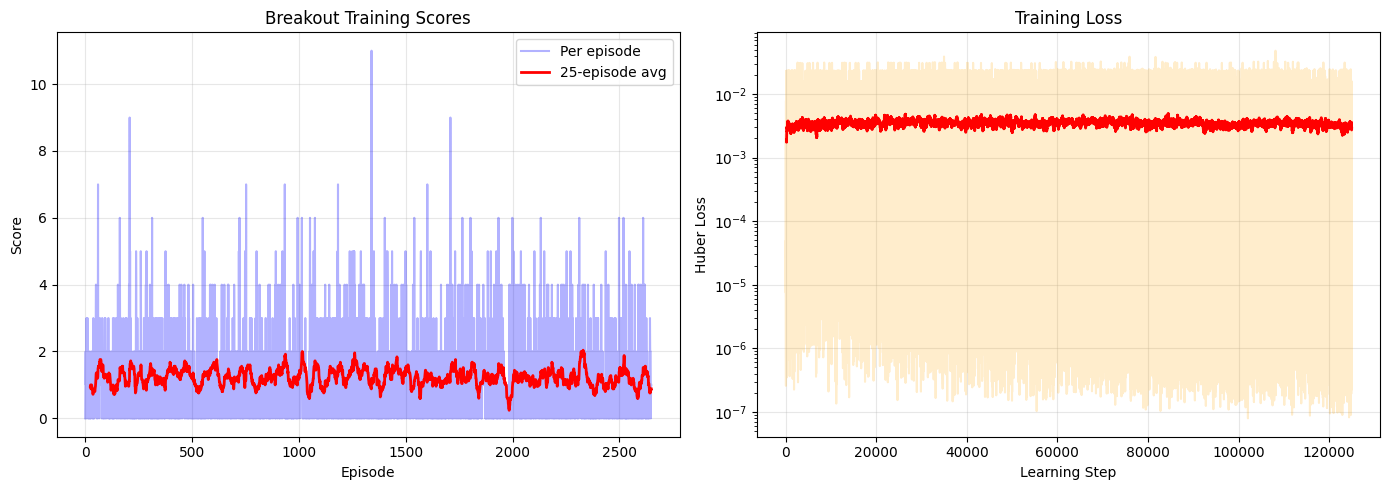

In [39]:
# Plot training results
plot_breakout_results(breakout_scores, agent.training_losses)


In [33]:
# ============================================================
# Cell: Simulate and Record Trained Agent
# Purpose: Record a video of the trained agent playing Breakout.
# ============================================================

def simulate_breakout(agent=None, n_steps=5000, seed=SEED):
    """Run Breakout with optional agent and record video."""
    video_dir = tempfile.tempdir or tempfile.gettempdir()
    
    env = make_breakout_env(render_mode="rgb_array", seed=seed)
    env = RecordVideo(env, video_dir, episode_trigger=lambda ep: ep == 0)
    
    state = start_episode(env)
    
    for _ in range(n_steps):
        if agent is not None:
            action = agent.select_action(state, training=False)
        else:
            action = env.action_space.sample()
        
        obs, reward, terminated, truncated, _ = env.step(action)
        
        if terminated or truncated:
            obs, _ = env.reset()
            obs, _, _, _, _ = env.step(1)
        
        state = np.stack([state[1], obs], axis=0)
    
    env.close()
    
    # Display video
    mp4_files = sorted(glob.glob(os.path.join(video_dir, "**", "*.mp4"), recursive=True))
    if mp4_files:
        from IPython.display import Video, display
        display(Video(mp4_files[-1], embed=True, width=640, height=840))
    else:
        print("No video recorded.")

simulate_breakout(agent)


### Final Remark
Not bad for 16 mins training on a complex task, you can do much better if traning for longer and tuning the hyperparameters!

--- 

## TO DO: WRITE YOUR REFLECTION IN THIS CELL

COMPARING THE IMPLEMENTATION OF THE REPLAY BUFFER, Q-NETWORK, AND THE AGENT ACROSS TWO ENVs

For the replay buffer, MountainCar stores small continuous state vectors (position and velocity), so memory is not an issue and transitions are simple. Breakout stores stacked image frames, so memory usage is much larger.

For the Q-network, MountainCar uses a small MLP since the state is low-dimensional and does not require spatial reasoning. Breakout uses a CNN followed by fully connected layers because spatial features in images are important. This makes the Breakout network much larger and harder to optimize.

For the agent and updates, MountainCar uses hard target updates every fixed number of episodes. Breakout instead uses soft target updates with Polyak averaging, which makes target changes smoother. Breakout also clips rewards to [-1,1], which helps control the scale of updates and presumably improves stability.

For training behavior, MountainCar converged faster and was able to consitently solve the problem, while Breakout improved slowly and remained modest in its performance in the game. This is expected as MountainCar has a simple state space and consistent rewards, while Breakout has high-dimensional input and delayed rewards.

---


## Summary

In this lab, you:

1. **Explored** the Mountain Car environment and understood why it is a challenging benchmark for RL.
2. **Implemented** a complete DQN agent from scratch, including the replay buffer, Q-network, epsilon-greedy policy, and target network.
3. **Trained** the agent and visualized its learning progress through training curves.
4. **Evaluated** the learned policy qualitatively (trajectory plots, policy heatmaps) and quantitatively (evaluation episodes).
5. **Ran ablation experiments** to understand the contribution of each hyperparameter and design choice.


### Key Takeaways

- **Experience replay** breaks temporal correlations and improves data efficiency.
- **Target networks** stabilize training by providing consistent TD targets.
- **Epsilon-greedy** exploration is simple but can struggle with sparse rewards — the decay schedule matters a lot.
- **Hyperparameter sensitivity:** DQN performance is highly sensitive to learning rate, buffer size, and discount factor. Always tune carefully!
- **Mountain Car** is deceptively hard due to its sparse reward — it forces the agent to discover a multi-step strategy through exploration alone.
- **Convolutional Q-networks** allow DQN to operate directly on pixel observations, making the same algorithmic core (replay buffer, target network, ε-greedy) applicable to visually complex environments like Breakout.
- **Frame stacking** (two consecutive frames as a single state) gives the network a sense of motion — critical for Breakout where the ball's velocity is not observable from a single frame.
- **Environment-specific handling matters:** Breakout requires firing to launch the ball after resets and life losses, and uses a slower ε-decay and longer training horizon than Mountain Car. The same DQN algorithm needs different tuning per environment.

### Hyperparameter Insights

| Hyperparameter | Effect of Increasing | Typical Range |
|---------------|---------------------|---------------|
| Learning rate | Faster but unstable learning | 1e-5 to 1e-3 |
| Batch size | More stable gradients, slower updates | 32 to 128 |
| Buffer size | Better sample diversity, more memory | 10K to 1M |
| Epsilon decay | Slower transition to exploitation | 10K to 1M steps |
| Target update | More stable but slower adaptation | 1K to 10K steps |

### Limitations of DQN

1. **Overestimation bias**: Fixed by Double DQN
2. **Uniform sampling**: Fixed by Prioritized Experience Replay
3. **Single-stream architecture**: Fixed by Dueling DQN
4. **Discrete actions only**: Use DDPG/SAC for continuous actions